In [67]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

def process_task_data(df, task):
    task_data = df[df['task'] == task]
    print(f"{task.capitalize()} data shape:", task_data.shape)
    return task_data

def create_plots(task_data, task, metric, save = False):
    metric_data = task_data[task_data['metric'] == metric]
    metric_data['value'] = metric_data['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    print(f"Data for {metric}:")
    print(metric_data.head(3))

    if metric_data.empty:
        print(f"Warning: No data found for metric '{metric}'")
        axes[i].text(0.5, 0.5, 'No Data', ha='center', va='center', fontsize=12, fontweight='bold')

    # Create a new row for each config value
    unique_configs = metric_data['config'].unique()
    num_configs = len(unique_configs)
    fig.set_figheight(6 * num_configs)  # Adjust figure height based on number of configs

    for j, config in enumerate(unique_configs):
        config_data = metric_data[metric_data['config'] == config]
        ax = plt.subplot(num_configs, len(metrics), i + 1 + j * len(metrics))
        
        sns.barplot(data=config_data, x='finetune_algo', y='value', hue='type', ax=ax, order=['n/a', 'lora', 'full'])
        ax.set_title(f'{metric} - {config}')
        ax.set_xlabel('Finetune Algorithm')
        ax.set_ylabel(metric)
        ax.tick_params(axis='x', rotation=45)


        
        if i == len(metrics) - 1:  # Only add legend to the last subplot in each row
            ax.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')
        else:
            ax.legend().remove()

    
    

In [68]:
import os 
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv('combined_metrics.csv')



The following groups have an incorrect number of values:
Group ('erase_ship', 'before fine-tuning') has 4 values:
     algo    change    task      config finetune_algo finetune_task  \
98   MACE  baseline  object  erase_ship          none          none   
122  MACE  baseline  object  erase_ship          none          none   
146  MACE  baseline  object  erase_ship          none          none   
149  MACE  baseline  object  erase_ship          none          none   

    finetune_prompts           prompts_csv  seed    type    metric  value  \
98              none  object_ship_concepts     1  erased  clip_acc  0.105   
122             none  object_ship_concepts     2  erased  clip_acc  0.105   
146             none  object_ship_concepts     0  erased  clip_acc  0.060   
149             none  object_ship_concepts     0  erased  clip_acc  0.065   

                  phase  
98   before fine-tuning  
122  before fine-tuning  
146  before fine-tuning  
149  before fine-tuning  


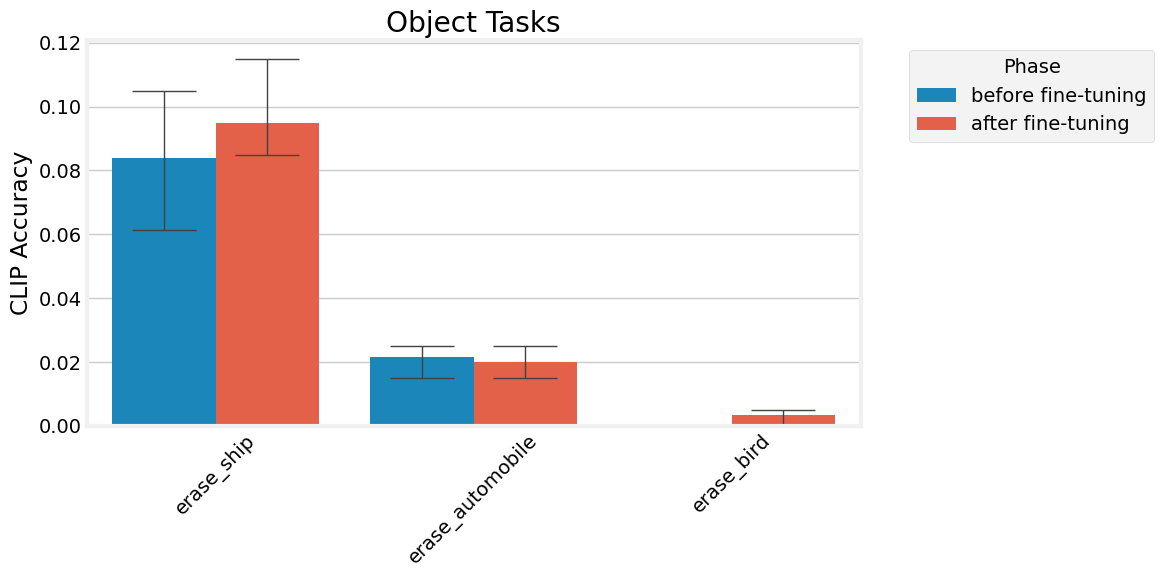

Figure saved as 'figures/warmup/object_warmup_impact.png'
The following groups have an incorrect number of values:
Group ('erase_art_100', 'after fine-tuning') has 4 values:
    algo    change task         config finetune_algo finetune_task  \
49  MACE  baseline  art  erase_art_100          lora           art   
65  MACE  baseline  art  erase_art_100          lora           art   
79  MACE  baseline  art  erase_art_100          lora           art   
81  MACE  baseline  art  erase_art_100          lora           art   

             finetune_prompts       prompts_csv  seed    type      metric  \
49  art_random_concepts_seed0  art_100_concepts     1  erased  clip_score   
65  art_random_concepts_seed0  art_100_concepts     2  erased  clip_score   
79  art_random_concepts_seed0  art_100_concepts     0  erased  clip_score   
81  art_random_concepts_seed0  art_100_concepts     0  erased  clip_score   

      value              phase  
49  21.6982  after fine-tuning  
65  21.6903  after fine

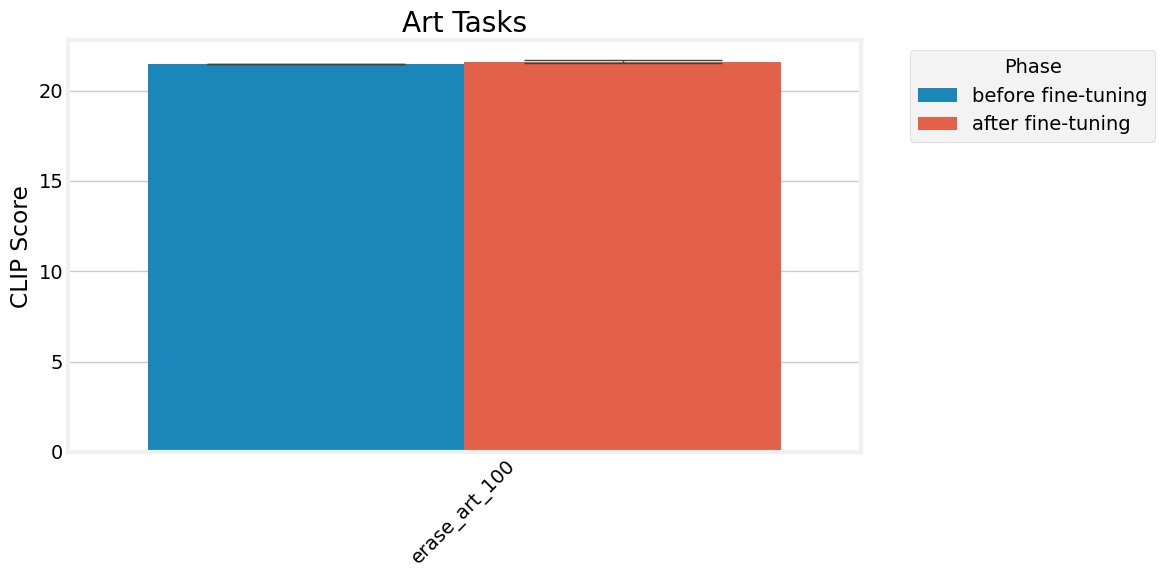

Figure saved as 'figures/warmup/art_warmup_impact.png'
The following groups have an incorrect number of values:
Group ('erase_cele_1', 'before fine-tuning') has 4 values:
     algo    change       task        config finetune_algo finetune_task  \
173  MACE  baseline  celebrity  erase_cele_1          none          none   
176  MACE  baseline  celebrity  erase_cele_1          none          none   
180  MACE  baseline  celebrity  erase_cele_1          none          none   
181  MACE  baseline  celebrity  erase_cele_1          none          none   

    finetune_prompts           prompts_csv  seed    type metric  value  \
173             none  celebrity_1_concepts     1  erased    GCD    0.0   
176             none  celebrity_1_concepts     2  erased    GCD    0.0   
180             none  celebrity_1_concepts     0  erased    GCD    0.0   
181             none  celebrity_1_concepts     0  erased    GCD    0.0   

                  phase  
173  before fine-tuning  
176  before fine-tuning  

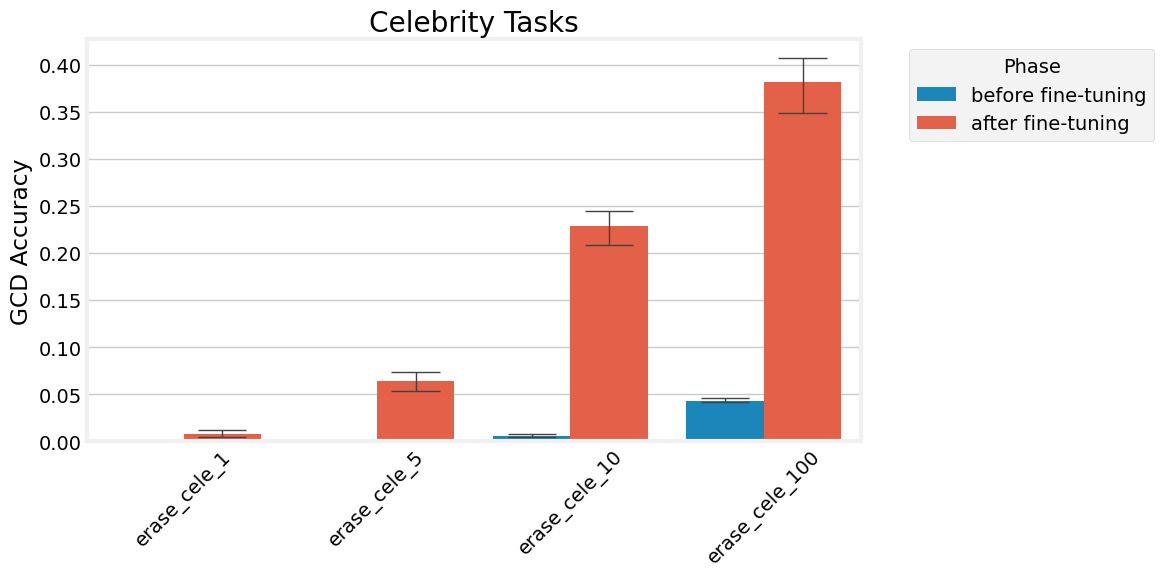

Figure saved as 'figures/warmup/celebrity_warmup_impact.png'


In [69]:
change = 'warmup'
change_str = 'baseline'
metric_map = {'object': 'clip_acc', 'art': 'clip_score', 'celebrity': 'GCD'}
metric_str = {'clip_acc': 'CLIP Accuracy', 'clip_score': 'CLIP Score', 'GCD': 'GCD Accuracy'}
    
for task in ['object', 'art', 'celebrity']:

    metric = metric_map[task]

    plt.style.use('fivethirtyeight')

    df_fig = df[df['change'].str.contains(change_str, na=False)]
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[(df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)) | (df_fig['finetune_prompts'] == 'none')]
    # Map 'type' column values: 0 -> "erased", 1 -> "others"
    if task == 'art':
        df_fig['type'] = df_fig['type'].map({"0": "erased", "1": "others"})
        
    #df_fig = df_fig[df_fig['finetune_task'] == task]
    #df_fig = df_fig[df_fig['type'] != 'others']
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))

    # Filter out 'full' type and keep only 'none' and 'lora'
    df_fig = df_fig[df_fig['finetune_algo'].isin(['none', 'lora'])]
    df_fig = df_fig[df_fig['finetune_task'].isin([task, 'none'])]
    df_fig = df_fig[df_fig['type'].isin(['erased'])]
    #print(df_fig)
    
    if task == 'celebrity':
        df_fig['config_num'] = df_fig['config'].str.extract('(\d+)$').astype(int)
        df_fig = df_fig.sort_values('config_num')
        custom_order = df_fig['config'].unique()
        df_fig = df_fig.drop('config_num', axis=1)


    # Create a new 'phase' column based on 'finetune_algo'
    df_fig['phase'] = df_fig['finetune_algo'].map({'none': 'before fine-tuning', 'lora': 'after fine-tuning'})

    # Create a single figure
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor('white')  # Set figure background to white
    ax.set_facecolor('white')  # Set axes background to white

    grouped = df_fig.groupby(['config', 'phase'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print("The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)
        
        # Raise an exception to halt execution
        #raise ValueError("Some groups have an incorrect number of values. Please check the data and try again.")
            
    sns.barplot(data=df_fig, x='config', y='value', hue='phase', ax=ax, order=df_fig['config'].unique(), capsize=0.5, err_kws={'linewidth': 1})

    ax.set_title(f'{task.capitalize()} Tasks')
    ax.set_xlabel('')
    #ax.set_xlabel('Task')
    ax.set_ylabel(metric_str[metric])
    ax.tick_params(axis='x', rotation=45)

    ax.legend(title='Phase', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    os.makedirs('figures/warmup', exist_ok=True)

    # Save the figure
    fig.savefig(f'figures/warmup/{task}_warmup_impact.png', dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Figure saved as 'figures/warmup/{task}_warmup_impact.png'")


Task object: The following groups have an incorrect number of values:
Group ('erase_ship', 'before fine-tuning') has 4 values:
     algo    change    task      config finetune_algo finetune_task  \
98   MACE  baseline  object  erase_ship          none          none   
122  MACE  baseline  object  erase_ship          none          none   
146  MACE  baseline  object  erase_ship          none          none   
149  MACE  baseline  object  erase_ship          none          none   

    finetune_prompts           prompts_csv  seed    type    metric  value  \
98              none  object_ship_concepts     1  erased  clip_acc  0.105   
122             none  object_ship_concepts     2  erased  clip_acc  0.105   
146             none  object_ship_concepts     0  erased  clip_acc  0.060   
149             none  object_ship_concepts     0  erased  clip_acc  0.065   

                  phase  
98   before fine-tuning  
122  before fine-tuning  
146  before fine-tuning  
149  before fine-tuning  
T

/tmp/ipykernel_305169/1868560439.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=32)
/tmp/ipykernel_305169/1868560439.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=32)
/tmp/ipykernel_305169/1868560439.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=32)
/tmp/ipykernel_305169/1868560439.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=32)


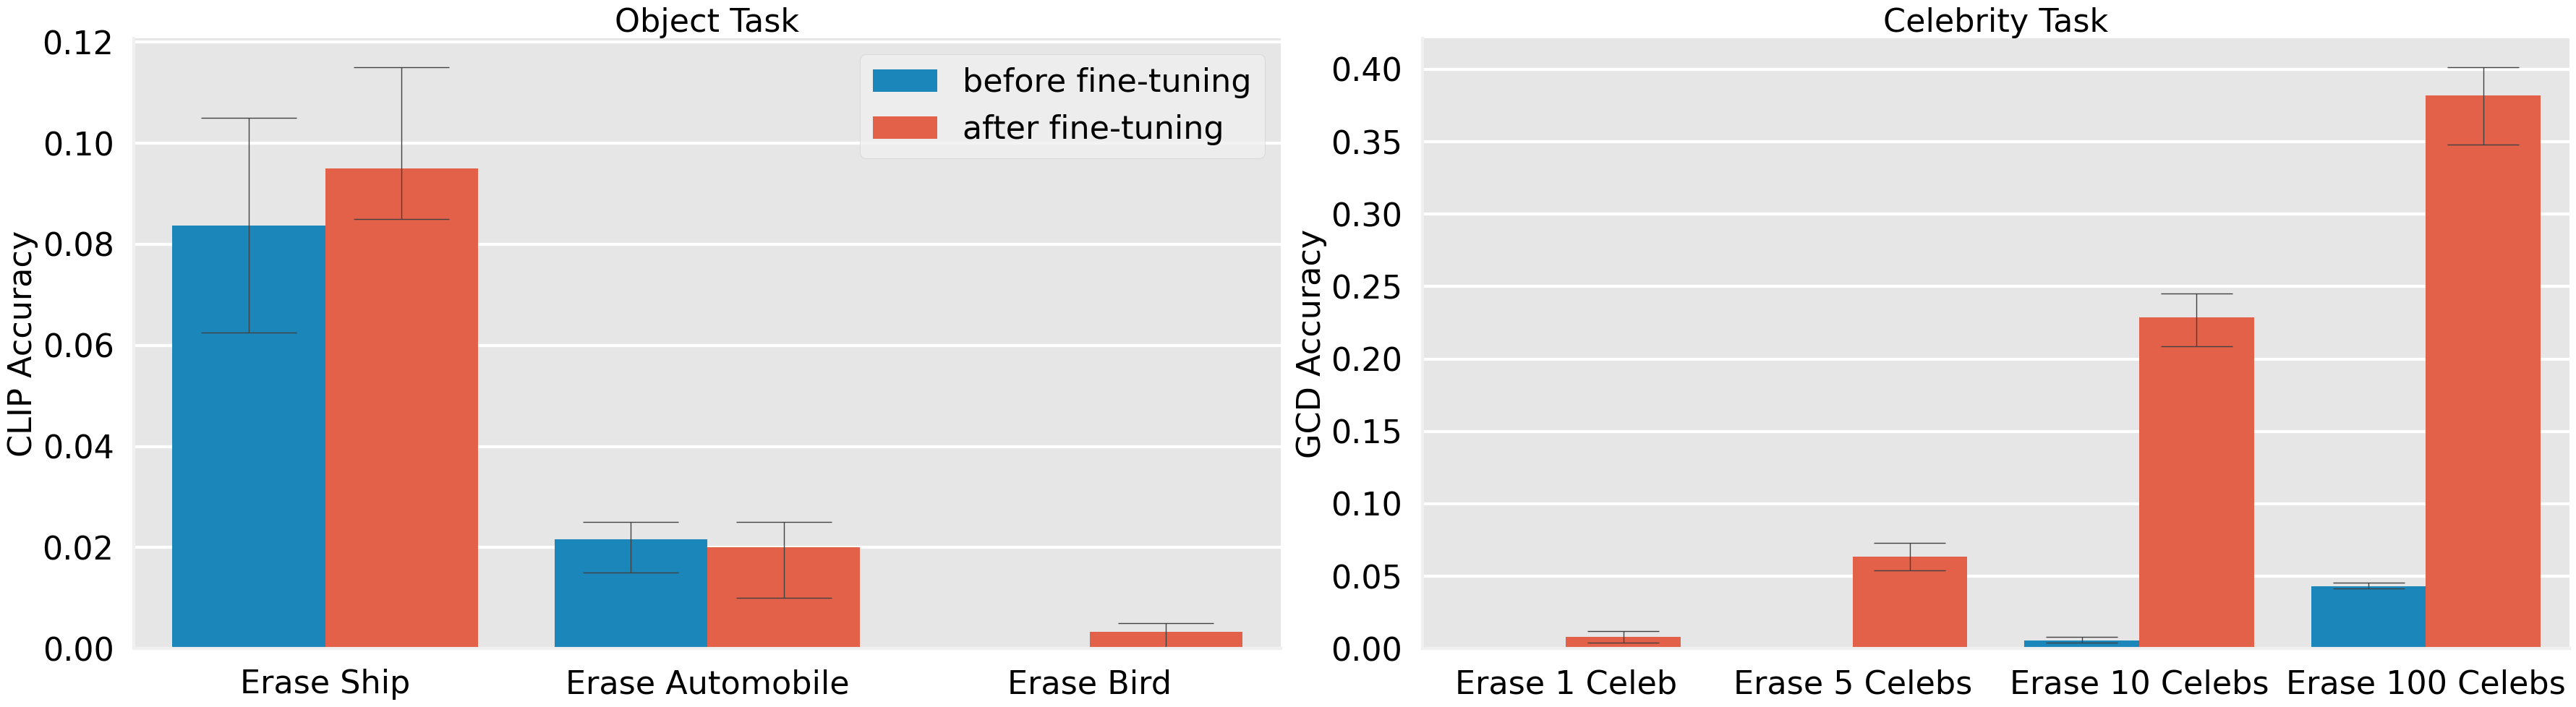

Figure saved as 'figures/warmup/all_tasks_warmup_impact.png'


In [70]:
# Create a main figure with subplots for each task
tasks = ['object', 'celebrity']
x_axis_labels = {
    'erase_ship': 'Erase Ship',
    'erase_bird': 'Erase Bird',
    'erase_automobile': 'Erase Automobile',
    'erase_cele_1': 'Erase 1 Celeb',
    'erase_cele_5': 'Erase 5 Celebs',
    'erase_cele_10': 'Erase 10 Celebs',
    'erase_cele_100': 'Erase 100 Celebs'
}

fig, axes = plt.subplots(1, len(tasks), figsize=(36, 10))
fig.patch.set_facecolor('white')  # Set figure background to white

change = 'warmup'
change_str = 'baseline'

for idx, task in enumerate(tasks):
    metric = metric_map[task]
    
    plt.style.use('fivethirtyeight')

    df_fig = df[df['change'].str.contains(change_str, na=False)]
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[(df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)) | (df_fig['finetune_prompts'] == 'none')]
    df_fig = df_fig[df_fig['finetune_task'].isin([task, 'none'])]
    df_fig = df_fig[df_fig['type'].isin(['erased'])]
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    if task == 'art':
        df_fig['type'] = df_fig['type'].map({"0": "erased", "1": "others"})

    df_fig = df_fig[df_fig['finetune_algo'].isin(['none', 'lora'])]

    df_fig['phase'] = df_fig['finetune_algo'].map({'none': 'before fine-tuning', 'lora': 'after fine-tuning'})

    if task == 'celebrity':
        df_fig['config_num'] = df_fig['config'].str.extract('(\d+)$').astype(int)
        df_fig = df_fig.sort_values('config_num')
        custom_order = df_fig['config'].unique()
        df_fig = df_fig.drop('config_num', axis=1)

    ax = axes[idx]
    ax.set_facecolor('white')  # Set axes background to white

    grouped = df_fig.groupby(['config', 'phase'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print(f"Task {task}: The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)
    
    df_fig['config'] = df_fig['config'].apply(lambda x: x_axis_labels[x])
    sns.barplot(data=df_fig, x='config', y='value', hue='phase', ax=ax, order=df_fig['config'].unique(), capsize=0.5, err_kws={'linewidth': 1})

    # remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    
    ax.set_title(f'{task.capitalize()} Task', fontsize=32)
    ax.set_xlabel('')
    ax.set_ylabel(metric_str[metric], fontsize=32)
    # set font size of legend, x axis labels, y axis labels
    
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=32)
    
    # Increase space between x-axis labels and plot
    ax.tick_params(axis='x', which='major', pad=20)
    ax.tick_params(axis='y', which='major', pad=20)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=32)

    ax.set_facecolor('#E6E6E6')  # Light gray background
    ax.grid(color='white', linestyle='-', linewidth=3, axis='y')
    ax.set_axisbelow(True)  # Ensure grid is behind the bars


    handles, labels = ax.get_legend_handles_labels()
    if idx == 0:  # Only show legend for the last subplot
        ax.legend(handles, labels, title='', loc='upper right', fontsize=32)
    else:
        ax.legend().remove()

plt.tight_layout()
plt.show()

# Save the figure
os.makedirs('figures/warmup', exist_ok=True)
fig.savefig(f'figures/warmup/all_tasks_warmup_impact.png', dpi=300, bbox_inches='tight', facecolor='white')
print(f"Figure saved as 'figures/warmup/all_tasks_warmup_impact.png'")




/tmp/ipykernel_305169/1702080132.py:44: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='change_value', y='value', hue='type', ax=ax, order=df_fig['change_value'].unique(), capsize=0.5, errwidth=1)


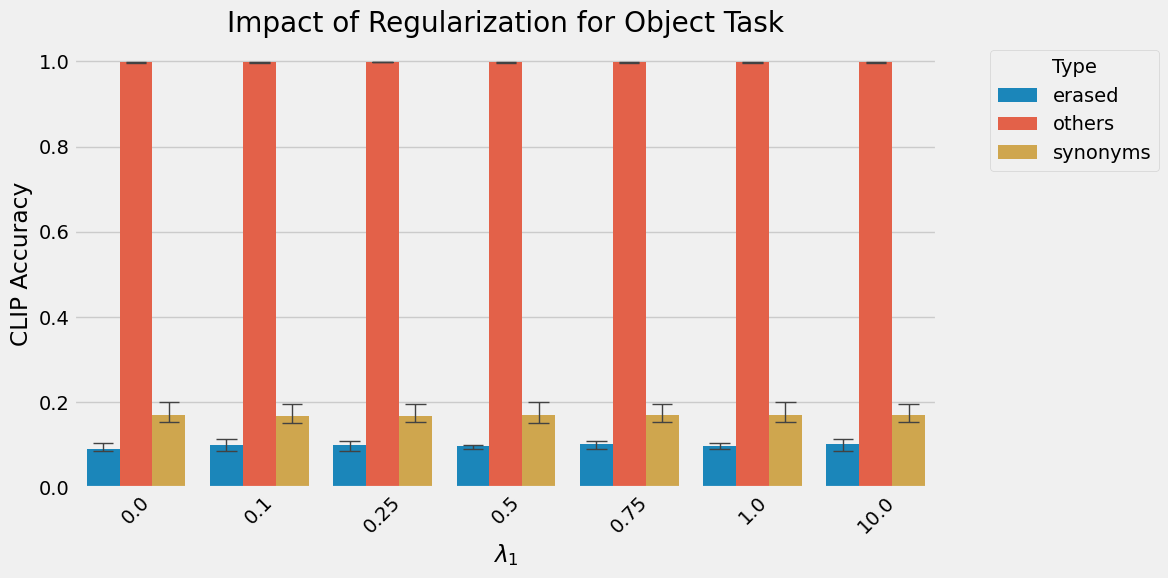

Figure saved as 'figures/regularization/object_regularization_impact.png'
The following groups have an incorrect number of values:
Group ('car_reg=0.0', 'erased') has 6 values:
    algo       change task         config finetune_algo finetune_task  \
11  MACE  car_reg=0.0  art  erase_art_100          lora           art   
21  MACE  car_reg=0.0  art  erase_art_100          lora           art   
15  MACE  car_reg=0.0  art  erase_art_100          lora           art   
17  MACE  car_reg=0.0  art  erase_art_100          lora           art   
19  MACE  car_reg=0.0  art  erase_art_100          lora           art   
13  MACE  car_reg=0.0  art  erase_art_100          lora           art   

             finetune_prompts       prompts_csv  seed    type      metric  \
11  art_random_concepts_seed0  art_100_concepts     0  erased  clip_score   
21  art_random_concepts_seed0  art_100_concepts     2  erased  clip_score   
15  art_random_concepts_seed0  art_100_concepts     1  erased  clip_score   
17 

/tmp/ipykernel_305169/1702080132.py:44: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='change_value', y='value', hue='type', ax=ax, order=df_fig['change_value'].unique(), capsize=0.5, errwidth=1)


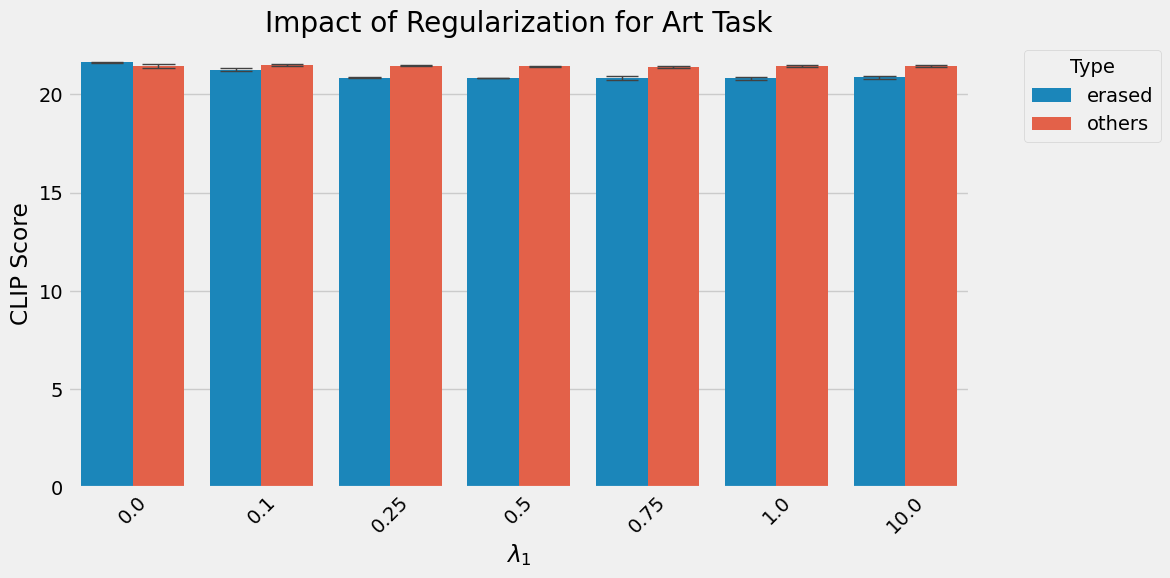

Figure saved as 'figures/regularization/art_regularization_impact.png'
The following groups have an incorrect number of values:
Group ('car_reg=0.0', 'erased') has 5 values:
    algo       change       task         config finetune_algo finetune_task  \
23  MACE  car_reg=0.0  celebrity  erase_cele_10          lora     celebrity   
25  MACE  car_reg=0.0  celebrity  erase_cele_10          lora     celebrity   
27  MACE  car_reg=0.0  celebrity  erase_cele_10          lora     celebrity   
28  MACE  car_reg=0.0  celebrity  erase_cele_10          lora     celebrity   
31  MACE  car_reg=0.0  celebrity  erase_cele_10          lora     celebrity   

                   finetune_prompts            prompts_csv  seed    type  \
23  celebrity_random_concepts_seed0  celebrity_10_concepts     1  erased   
25  celebrity_random_concepts_seed0  celebrity_10_concepts     2  erased   
27  celebrity_random_concepts_seed0  celebrity_10_concepts     0  erased   
28  celebrity_random_concepts_seed0  celebrity_

/tmp/ipykernel_305169/1702080132.py:44: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='change_value', y='value', hue='type', ax=ax, order=df_fig['change_value'].unique(), capsize=0.5, errwidth=1)


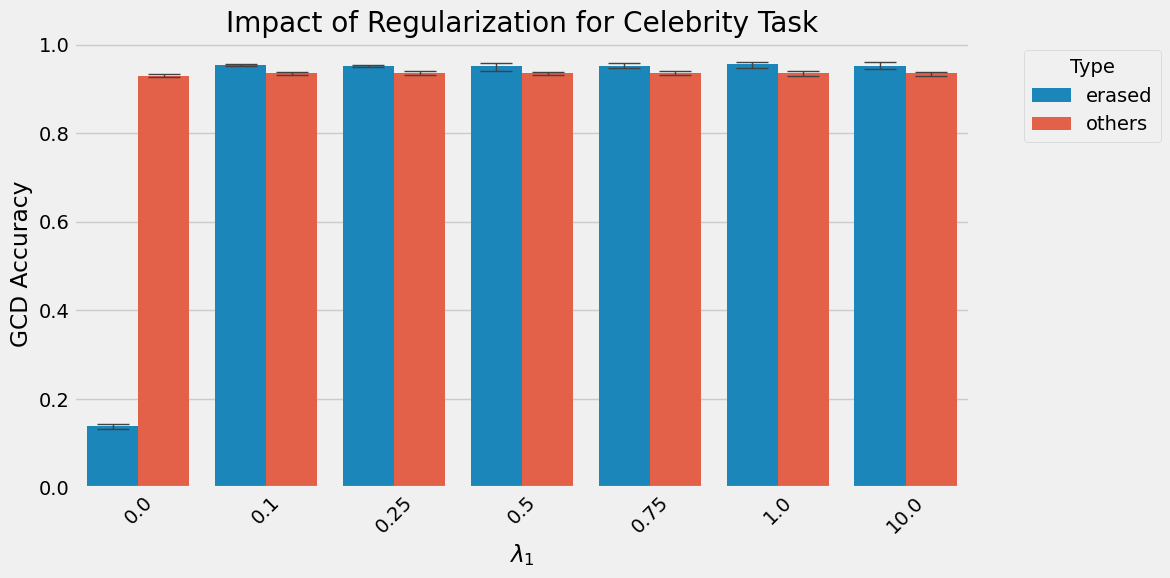

Figure saved as 'figures/regularization/celebrity_regularization_impact.png'


In [71]:
change = 'regularization'
change_str = 'car_reg'
task = 'object'

    
for task in ['object', 'art', 'celebrity']:

    metric = metric_map[task]
    plt.style.use('fivethirtyeight')

    df_fig = df[df['change'].str.contains(change_str, na=False)]
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)]
    df_fig = df_fig[df_fig['finetune_task'].isin([task, 'none'])]
    df_fig = df_fig[(df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)) | (df_fig['finetune_prompts'] == 'none')]
    #df_fig = df_fig[df_fig['type'] != 'others']
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    if task == 'art':
        df_fig['type'] = df_fig['type'].map({"0": "erased", "1": "others"})

    # Filter out 'full' type and keep only 'n/a' and 'lora'
    df_fig = df_fig[df_fig['finetune_algo'].isin(['n/a', 'lora'])]

    # Extract the numeric value from 'change' column and sort
    df_fig['change_value'] = df_fig['change'].str.extract('(\d+(?:\.\d+)?)').astype(float)
    df_fig = df_fig.sort_values('change_value')

    # Create a single figure
    fig, ax = plt.subplots(figsize=(12, 6))
    #fig.suptitle(f'{task.capitalize()} Task', fontsize=16)

    grouped = df_fig.groupby(['change', 'type'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print("The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)

    # Plot the data with sorted x-axis and smaller confidence interval bars
    sns.barplot(data=df_fig, x='change_value', y='value', hue='type', ax=ax, order=df_fig['change_value'].unique(), capsize=0.5, errwidth=1)

    ax.set_title(f'Impact of Regularization for {task.capitalize()} Task')
    ax.set_xlabel(r'$\lambda_1$')
    ax.set_ylabel(metric_str[metric])
    ax.tick_params(axis='x', rotation=45)

    ax.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    # Create the 'figures/regularization' directory if it doesn't exist
    import os
    os.makedirs('figures/regularization', exist_ok=True)

    # Save the figure
    fig.savefig(f'figures/regularization/{task}_regularization_impact.png', dpi=300, bbox_inches='tight')
    print(f"Figure saved as 'figures/regularization/{task}_regularization_impact.png'")


/tmp/ipykernel_305169/2902481299.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)
/tmp/ipykernel_305169/2902481299.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=24)
/tmp/ipykernel_305169/2902481299.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=32)
/tmp/ipykernel_305169/2902481299.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=32)


Task celebrity: The following groups have an incorrect number of values:
Group ('car_reg=0.0', 'erased') has 5 values:
    algo       change       task         config finetune_algo finetune_task  \
23  MACE  car_reg=0.0  celebrity  erase_cele_10          lora     celebrity   
25  MACE  car_reg=0.0  celebrity  erase_cele_10          lora     celebrity   
27  MACE  car_reg=0.0  celebrity  erase_cele_10          lora     celebrity   
28  MACE  car_reg=0.0  celebrity  erase_cele_10          lora     celebrity   
31  MACE  car_reg=0.0  celebrity  erase_cele_10          lora     celebrity   

                   finetune_prompts            prompts_csv  seed    type  \
23  celebrity_random_concepts_seed0  celebrity_10_concepts     1  erased   
25  celebrity_random_concepts_seed0  celebrity_10_concepts     2  erased   
27  celebrity_random_concepts_seed0  celebrity_10_concepts     0  erased   
28  celebrity_random_concepts_seed0  celebrity_10_concepts     0  erased   
31  celebrity_random_conce

/tmp/ipykernel_305169/2902481299.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)
/tmp/ipykernel_305169/2902481299.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=24)
/tmp/ipykernel_305169/2902481299.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=32)
/tmp/ipykernel_305169/2902481299.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=32)


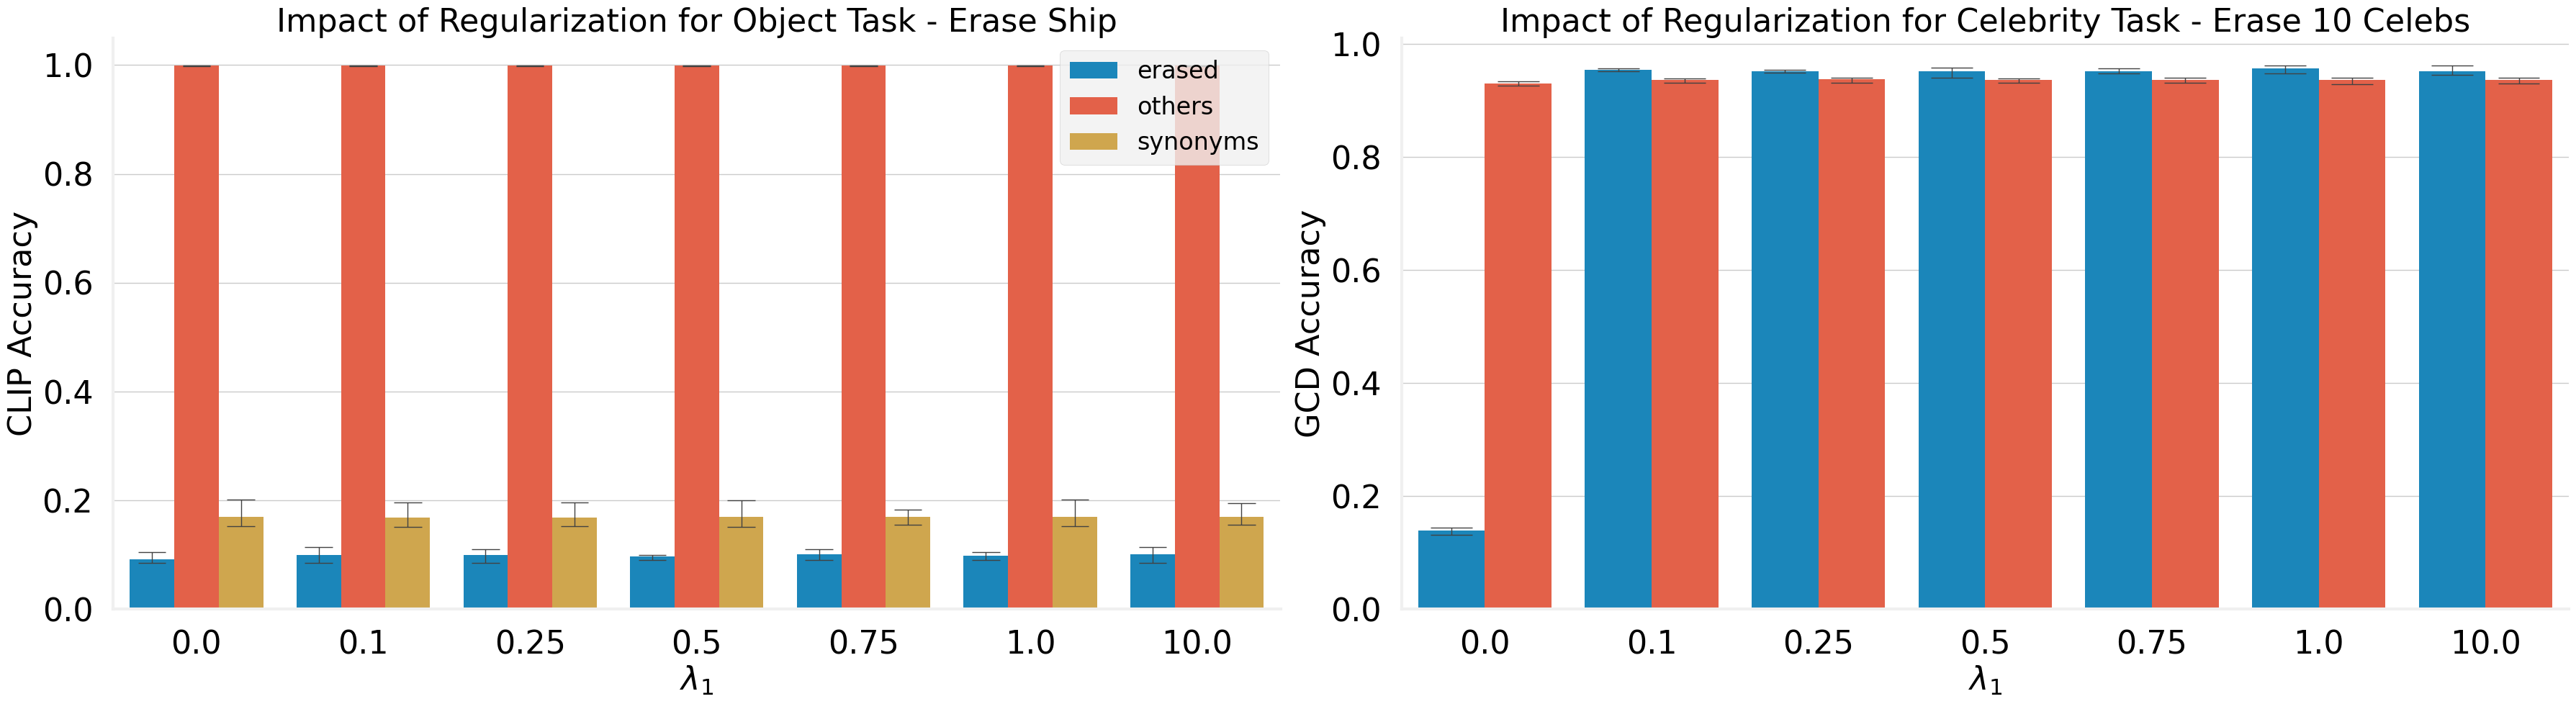

Figure saved as 'figures/regularization/all_tasks_regularization_impact.png'


In [72]:
# Create a main figure with subplots for each task
tasks = ['object', 'celebrity']
x_axis_labels = {
    'erase_ship': 'Erase Ship',
    'erase_bird': 'Erase Bird',
    'erase_automobile': 'Erase Automobile',
    'erase_cele_1': 'Erase 1 Celeb',
    'erase_cele_5': 'Erase 5 Celebs',
    'erase_cele_10': 'Erase 10 Celebs',
    'erase_cele_100': 'Erase 100 Celebs'
}

fig, axes = plt.subplots(1, len(tasks), figsize=(36, 10))
fig.patch.set_facecolor('white')  # Set figure background to white

change = 'regularization'
change_str = 'car_reg'

for idx, task in enumerate(tasks):
    metric = metric_map[task]
    
    plt.style.use('fivethirtyeight')

    df_fig = df[df['change'].str.contains(change_str, na=False)]
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)]
    df_fig = df_fig[df_fig['finetune_task'].isin([task, 'none'])]
    #df_fig = df_fig[df_fig['type'].isin(['erased', 'synonyms'])]
    df_fig = df_fig[(df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)) | (df_fig['finetune_prompts'] == 'none')]
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    if task == 'art':
        df_fig['type'] = df_fig['type'].map({"0": "erased", "1": "others"})

    # Filter out 'full' type and keep only 'n/a' and 'lora'
    df_fig = df_fig[df_fig['finetune_algo'].isin(['n/a', 'lora'])]

    ax = axes[idx]
    ax.set_facecolor('white')  # Set axes background to white

    df_fig['change_value'] = df_fig['change'].str.extract('(\d+(?:\.\d+)?)').astype(float)
    df_fig = df_fig.sort_values('change_value')

    grouped = df_fig.groupby(['change', 'type'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print(f"Task {task}: The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)
    
    df_fig['config'] = df_fig['config'].apply(lambda x: x_axis_labels.get(x, x))
    sns.barplot(data=df_fig, x='change_value', y='value', hue='type', ax=ax, order=df_fig['change_value'].unique(), capsize=0.5, err_kws={'linewidth': 1})

    # remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    
    ax.set_title(f'Impact of Regularization for {task.capitalize()} Task - {df_fig["config"].iloc[0]}', fontsize=32)
    ax.set_xlabel(r'$\lambda_1$', fontsize=32)
    ax.tick_params(axis='x', rotation=0)

    # set font size of legend, x axis labels, y axis labels
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)
    
    # Increase space between x-axis labels and plot
    ax.tick_params(axis='x', which='major', pad=20)
    ax.tick_params(axis='y', which='major', pad=20)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=24)
    
    ax.set_ylabel(metric_str[metric], fontsize=32)
    # set font size of legend, x axis labels, y axis labels
    
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=32)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=32)

    ax.set_facecolor('#E6E6E6')  # Light gray background
    ax.grid(color='white', linestyle='-', linewidth=3, axis='y')
    ax.set_axisbelow(True)  # Ensure grid is behind the bars


    handles, labels = ax.get_legend_handles_labels()
    if idx == 0:  # Only show legend for the first subplot
        ax.legend(handles, labels, title='', loc='upper right', fontsize=24)
    else:
        ax.legend().remove()

plt.tight_layout()
plt.show()

# Save the figure
os.makedirs('figures/regularization', exist_ok=True)
fig.savefig(f'figures/regularization/all_tasks_regularization_impact.png', dpi=300, bbox_inches='tight', facecolor='white')
print(f"Figure saved as 'figures/regularization/all_tasks_regularization_impact.png'")

The following groups have an incorrect number of values:
Group ('lora', 'erased') has 9 values:
     algo    change    task            config finetune_algo finetune_task  \
110  MACE  baseline  object        erase_ship          lora        object   
131  MACE  baseline  object        erase_ship          lora        object   
158  MACE  baseline  object        erase_ship          lora        object   
327  MACE  baseline  object  erase_automobile          lora        object   
333  MACE  baseline  object  erase_automobile          lora        object   
339  MACE  baseline  object  erase_automobile          lora        object   
458  MACE  baseline  object        erase_bird          lora        object   
464  MACE  baseline  object        erase_bird          lora        object   
470  MACE  baseline  object        erase_bird          lora        object   

                 finetune_prompts                 prompts_csv  seed    type  \
110  object_random_concepts_seed0        object_ship_c

/tmp/ipykernel_305169/1492553780.py:40: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='finetune_algo', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)


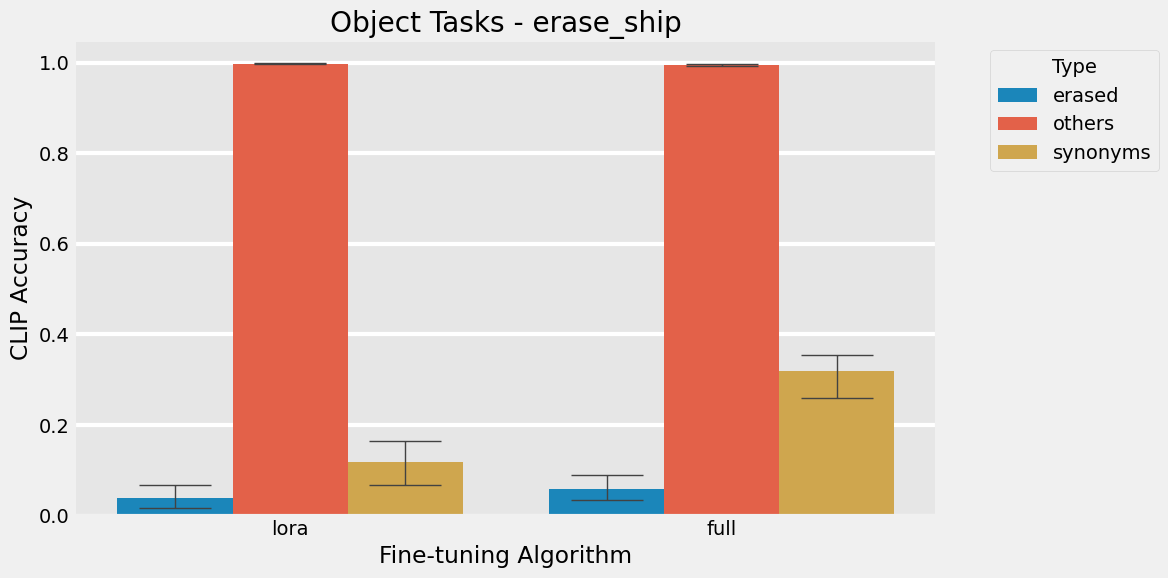

Figure saved as 'figures/finetuning/object_finetuning_comparison.png'
The following groups have an incorrect number of values:
Group ('lora', 'erased') has 4 values:
    algo    change task         config finetune_algo finetune_task  \
49  MACE  baseline  art  erase_art_100          lora           art   
65  MACE  baseline  art  erase_art_100          lora           art   
79  MACE  baseline  art  erase_art_100          lora           art   
81  MACE  baseline  art  erase_art_100          lora           art   

             finetune_prompts       prompts_csv  seed    type      metric  \
49  art_random_concepts_seed0  art_100_concepts     1  erased  clip_score   
65  art_random_concepts_seed0  art_100_concepts     2  erased  clip_score   
79  art_random_concepts_seed0  art_100_concepts     0  erased  clip_score   
81  art_random_concepts_seed0  art_100_concepts     0  erased  clip_score   

      value  
49  21.6982  
65  21.6903  
79  21.4977  
81  21.4977  
Group ('lora', 'others') ha

/tmp/ipykernel_305169/1492553780.py:40: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='finetune_algo', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)


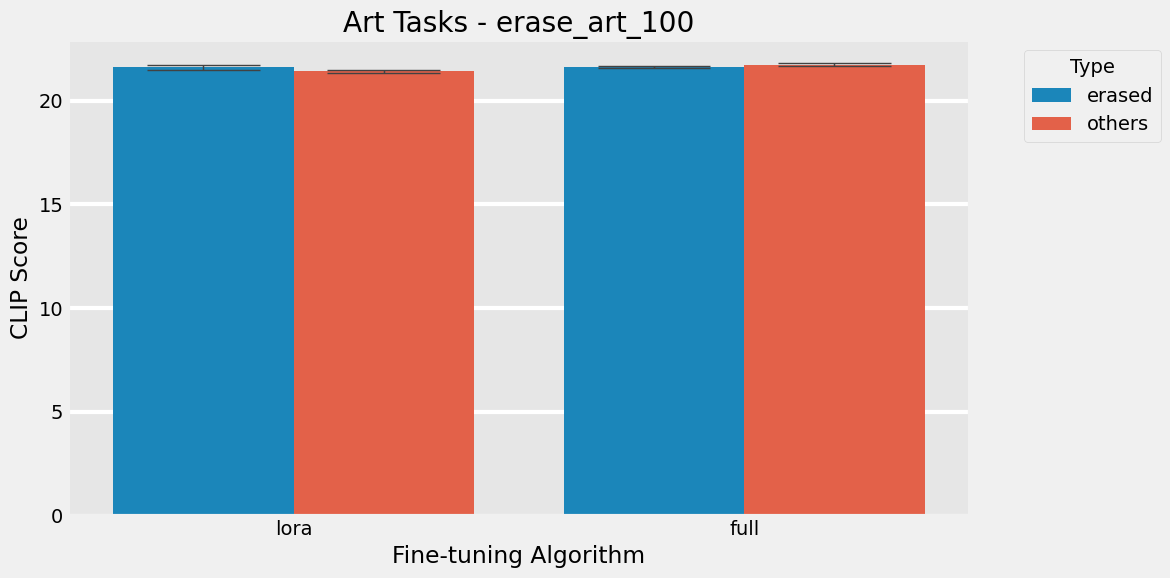

Figure saved as 'figures/finetuning/art_finetuning_comparison.png'
The following groups have an incorrect number of values:
Group ('full', 'others') has 2 values:
     algo    change       task         config finetune_algo finetune_task  \
227  MACE  baseline  celebrity  erase_cele_10          full     celebrity   
264  MACE  baseline  celebrity  erase_cele_10          full     celebrity   

                    finetune_prompts            prompts_csv  seed    type  \
227  celebrity_random_concepts_seed0  celebrity_10_concepts     1  others   
264  celebrity_random_concepts_seed0  celebrity_10_concepts     0  others   

    metric     value  
227    GCD  0.878433  
264    GCD  0.876473  
Group ('lora', 'erased') has 14 values:
     algo    change       task          config finetune_algo finetune_task  \
175  MACE  baseline  celebrity    erase_cele_1          lora     celebrity   
178  MACE  baseline  celebrity    erase_cele_1          lora     celebrity   
183  MACE  baseline  celebrity

/tmp/ipykernel_305169/1492553780.py:40: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='finetune_algo', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)


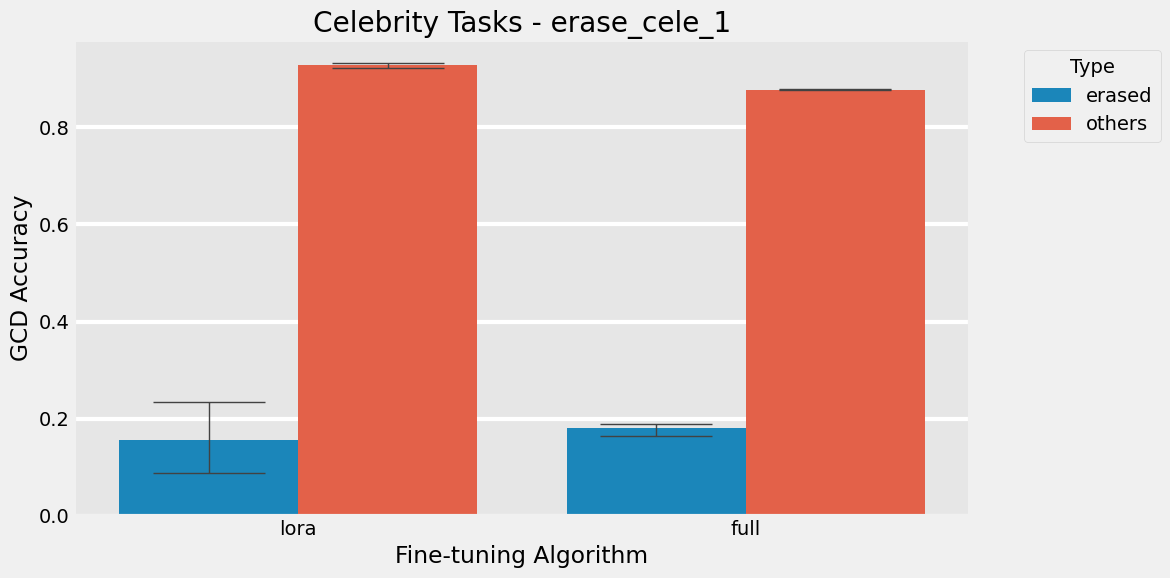

Figure saved as 'figures/finetuning/celebrity_finetuning_comparison.png'


In [73]:
change = 'finetuning'
change_str = 'baseline'

for task in ['object', 'art', 'celebrity']:

    metric = metric_map[task]

    plt.style.use('fivethirtyeight')

    df_fig = df[df['change'].str.contains(change_str, na=False)]
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)]
    df_fig = df_fig[df_fig['finetune_task'].isin([task, 'none'])]
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    if task == 'art':
        df_fig['type'] = df_fig['type'].map({"0": "erased", "1": "others"})

    # Filter for 'full' and 'lora' finetune_algo, and 'erase_cele_10' config
    df_fig = df_fig[df_fig['finetune_algo'].isin(['full', 'lora'])]
    #df_fig = df_fig[df_fig['config'] == 'erase_ship']

    # Include both 'erased' and 'others' types
    #df_fig = df_fig[df_fig['type'].isin(['erased', 'others'])]

    grouped = df_fig.groupby(['finetune_algo', 'type'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print("The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)

    # Create a single figure
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot the data with finetune_algo on x-axis and type as hue
    sns.barplot(data=df_fig, x='finetune_algo', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)

    ax.set_title(f'{task.capitalize()} Tasks - {df_fig["config"].iloc[0]}')
    ax.set_xlabel('Fine-tuning Algorithm')
    ax.set_ylabel(metric_str[metric])
    ax.tick_params(axis='x', rotation=0)

    ax.set_facecolor('#E6E6E6')  # Light gray background
    ax.grid(color='white', linestyle='-', linewidth=3, axis='y')
    ax.set_axisbelow(True)  # Ensure grid is behind the bars


    ax.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    # Create the 'figures/warmup' directory if it doesn't exist
    import os
    os.makedirs('figures/finetuning', exist_ok=True)

    # Save the figure
    fig.savefig(f'figures/finetuning/{task}_finetuning_comparison.png', dpi=300, bbox_inches='tight')
    print(f"Figure saved as 'figures/finetuning/{task}_finetuning_comparison.png'")


The following groups have an incorrect number of values:
Group ('lora', 'erased') has 9 values:
     algo    change    task            config finetune_algo finetune_task  \
110  MACE  baseline  object        erase_ship          lora        object   
131  MACE  baseline  object        erase_ship          lora        object   
158  MACE  baseline  object        erase_ship          lora        object   
327  MACE  baseline  object  erase_automobile          lora        object   
333  MACE  baseline  object  erase_automobile          lora        object   
339  MACE  baseline  object  erase_automobile          lora        object   
458  MACE  baseline  object        erase_bird          lora        object   
464  MACE  baseline  object        erase_bird          lora        object   
470  MACE  baseline  object        erase_bird          lora        object   

                 finetune_prompts                 prompts_csv  seed    type  \
110  object_random_concepts_seed0        object_ship_c

/tmp/ipykernel_305169/2010818282.py:59: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='finetune_algo', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)
/tmp/ipykernel_305169/2010818282.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)
/tmp/ipykernel_305169/2010818282.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=24)


The following groups have an incorrect number of values:
Group ('full', 'others') has 2 values:
     algo    change       task         config finetune_algo finetune_task  \
227  MACE  baseline  celebrity  erase_cele_10          full     celebrity   
264  MACE  baseline  celebrity  erase_cele_10          full     celebrity   

                    finetune_prompts            prompts_csv  seed    type  \
227  celebrity_random_concepts_seed0  celebrity_10_concepts     1  others   
264  celebrity_random_concepts_seed0  celebrity_10_concepts     0  others   

    metric     value  
227    GCD  0.878433  
264    GCD  0.876473  
Group ('lora', 'erased') has 14 values:
     algo    change       task          config finetune_algo finetune_task  \
175  MACE  baseline  celebrity    erase_cele_1          lora     celebrity   
178  MACE  baseline  celebrity    erase_cele_1          lora     celebrity   
183  MACE  baseline  celebrity    erase_cele_1          lora     celebrity   
222  MACE  baseline

/tmp/ipykernel_305169/2010818282.py:59: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='finetune_algo', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)
/tmp/ipykernel_305169/2010818282.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)
/tmp/ipykernel_305169/2010818282.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=24)


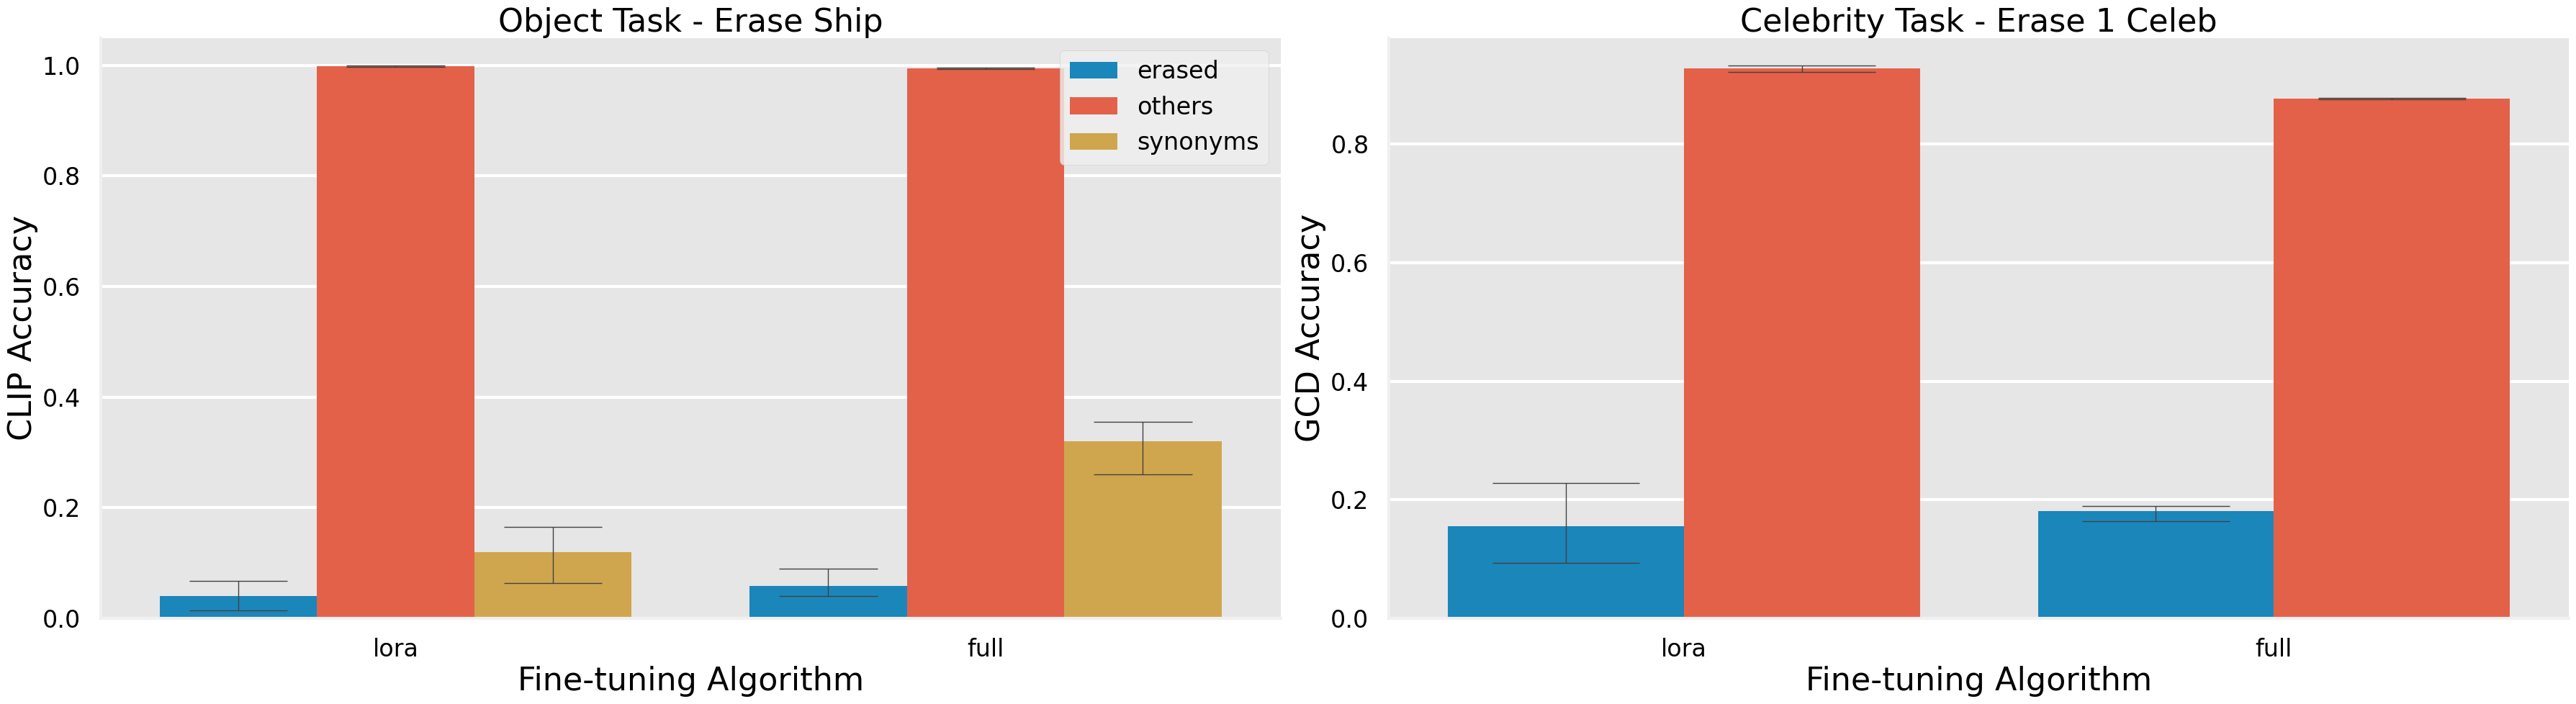

Figure saved as 'figures/finetuning/all_tasks_finetuning_comparison.png'


In [81]:
# Create a main figure with subplots for each task
tasks = ['object', 'celebrity']
x_axis_labels = {
    'erase_ship': 'Erase Ship',
    'erase_bird': 'Erase Bird',
    'erase_automobile': 'Erase Automobile',
    'erase_cele_1': 'Erase 1 Celeb',
    'erase_cele_5': 'Erase 5 Celebs',
    'erase_cele_10': 'Erase 10 Celebs',
    'erase_cele_100': 'Erase 100 Celebs'
}

fig, axes = plt.subplots(1, len(tasks), figsize=(36, 10))
fig.patch.set_facecolor('white')  # Set figure background to white

change = 'finetuning'
change_str = 'baseline'

for idx, task in enumerate(tasks):

    metric = metric_map[task]

    plt.style.use('fivethirtyeight')

    df_fig = df[df['change'].str.contains(change_str, na=False)]
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)]
    df_fig = df_fig[df_fig['finetune_task'].isin([task, 'none'])]
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    if task == 'art':
        df_fig['type'] = df_fig['type'].map({"0": "erased", "1": "others"})

    # Filter for 'full' and 'lora' finetune_algo, and 'erase_cele_10' config
    df_fig = df_fig[df_fig['finetune_algo'].isin(['full', 'lora'])]


    grouped = df_fig.groupby(['finetune_algo', 'type'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print("The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)

  
    ax = axes[idx]
    ax.set_facecolor('white')  # Set axes background to white
    
    # remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    

    sns.barplot(data=df_fig, x='finetune_algo', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)

    ax.set_title(f'{task.capitalize()} Task - {x_axis_labels[df_fig["config"].iloc[0]]}', fontsize=32)
    ax.set_xlabel('Fine-tuning Algorithm', fontsize=32)
    ax.set_ylabel(metric_str[metric], fontsize=32)
    ax.tick_params(axis='x', rotation=0)

    # set font size of legend, x axis labels, y axis labels
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)
    
    # Increase space between x-axis labels and plot
    ax.tick_params(axis='x', which='major', pad=20)
    ax.tick_params(axis='y', which='major', pad=20)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=24)

    ax.set_facecolor('#E6E6E6')  # Light gray background
    ax.grid(color='white', linestyle='-', linewidth=3, axis='y')
    ax.set_axisbelow(True)  # Ensure grid is behind the bars


    handles, labels = ax.get_legend_handles_labels()
    if idx == 0:  # Only show legend for the first subplot
        ax.legend(handles, labels, title='', loc='upper right', fontsize=24)
    else:
        ax.legend().remove()

plt.tight_layout()
plt.show()

# Save the figure
os.makedirs('figures/finetuning', exist_ok=True)
fig.savefig(f'figures/finetuning/all_tasks_finetuning_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
print(f"Figure saved as 'figures/finetuning/all_tasks_finetuning_comparison.png'")
    

/tmp/ipykernel_305169/4233703521.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_fig['prompt_number'].unique())
/tmp/ipykernel_305169/4233703521.py:45: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='finetune_prompts', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)


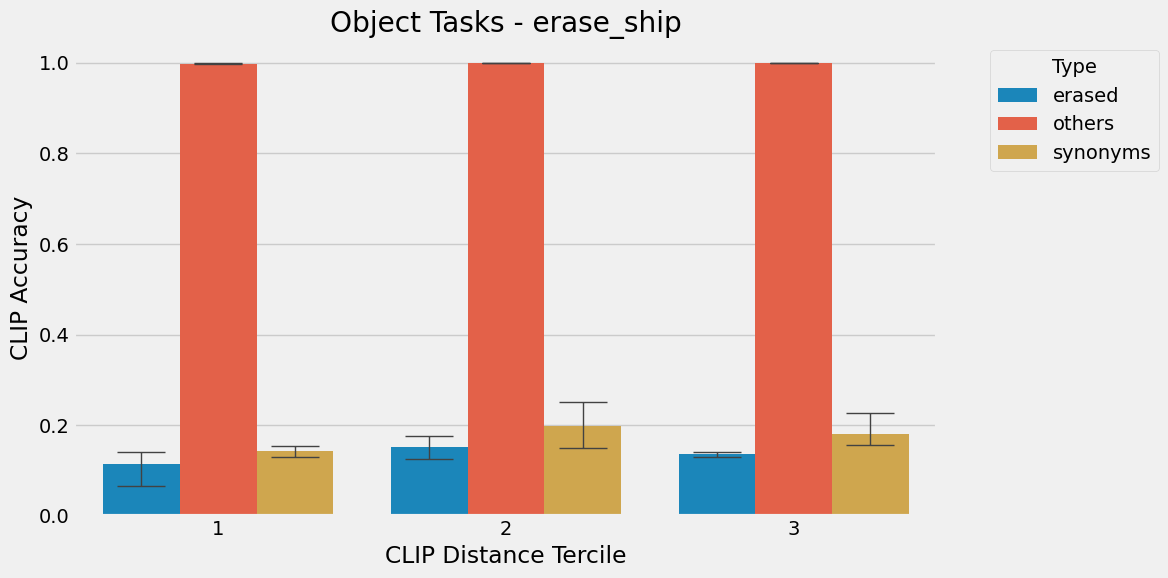

Figure saved as 'figures/clip_distance/object_clip_distance.png'


/tmp/ipykernel_305169/4233703521.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_fig['prompt_number'].unique())
/tmp/ipykernel_305169/4233703521.py:45: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='finetune_prompts', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)


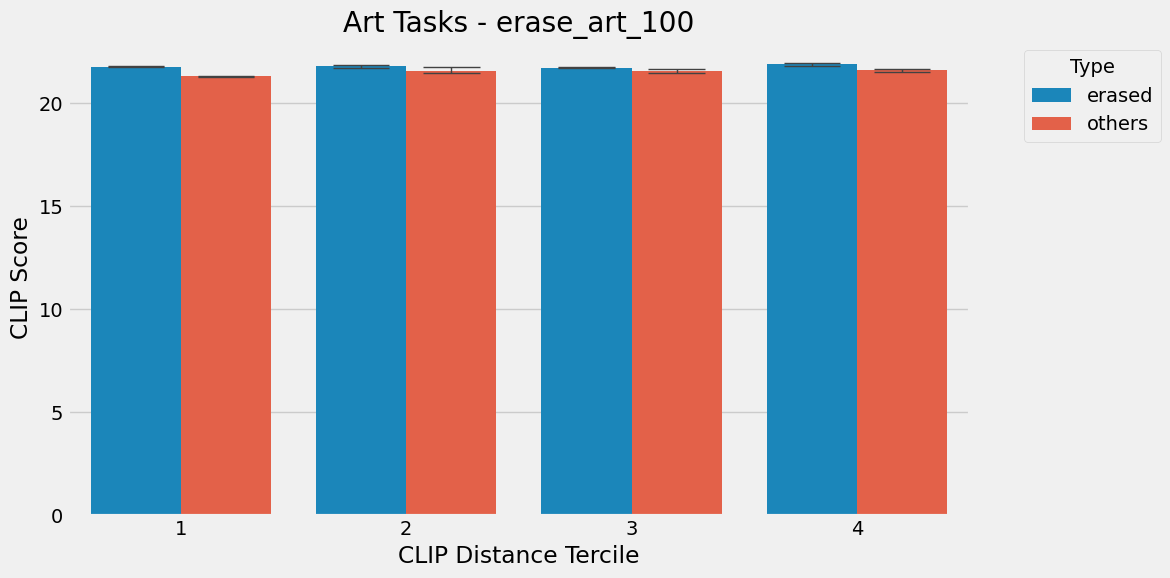

Figure saved as 'figures/clip_distance/art_clip_distance.png'


/tmp/ipykernel_305169/4233703521.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_fig['prompt_number'].unique())
/tmp/ipykernel_305169/4233703521.py:45: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='finetune_prompts', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)


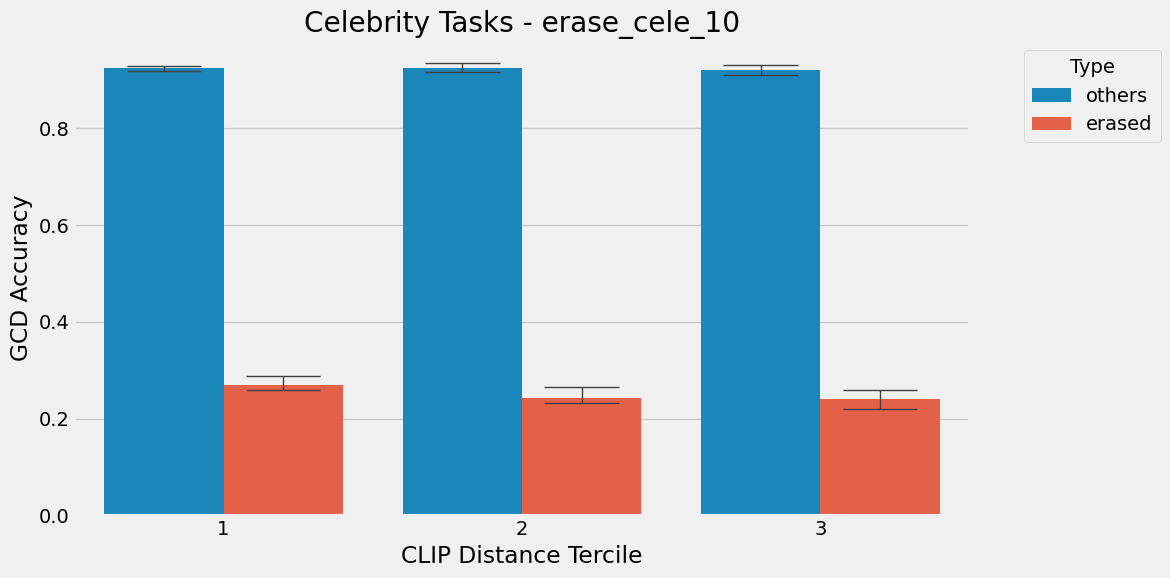

Figure saved as 'figures/clip_distance/celebrity_clip_distance.png'


In [75]:
change = 'CLIP Distance'
change_str = 'baseline'

for task in ['object', 'art', 'celebrity']:

    metric = metric_map[task]

    plt.style.use('fivethirtyeight')

    df_fig = df[df['change'].str.contains(change_str, na=False)]
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[df_fig['finetune_prompts'].str.contains("clip_", na=False)]
    if task == 'art':
        df_fig['type'] = df_fig['type'].map({"0": "erased", "1": "others"})
    
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    
    # Filter for 'full' and 'lora' finetune_algo, and 'erase_cele_10' config
    df_fig = df_fig[df_fig['finetune_algo'].isin(['lora'])]

    grouped = df_fig.groupby(['finetune_prompts', 'type'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print("The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)


    fig, ax = plt.subplots(figsize=(12, 6))

    # Sort the DataFrame based on the number at the end of finetune_prompts
    df_fig['prompt_number'] = df_fig['finetune_prompts'].str.extract('(\d+)$').astype(int)
    df_fig['prompt_number'] = df_fig['prompt_number'] + 1
    df_fig = df_fig.sort_values('prompt_number')
    
    custom_order = df_fig['finetune_prompts'].unique()
    ax.set_xlabel('CLIP Distance Tercile')
    ax.set_xticklabels(df_fig['prompt_number'].unique())

    # Plot the data with finetune_algo on x-axis and type as hue
    sns.barplot(data=df_fig, x='finetune_prompts', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)

    ax.set_title(f'{task.capitalize()} Tasks - {df_fig["config"].iloc[0]}')
    ax.set_ylabel(metric_str[metric])
    ax.tick_params(axis='x', rotation=0)

    ax.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    # Create the 'figures/warmup' directory if it doesn't exist
    import os
    os.makedirs('figures/clip_distance', exist_ok=True)

    # Save the figure
    fig.savefig(f'figures/clip_distance/{task}_clip_distance.png', dpi=300, bbox_inches='tight')
    print(f"Figure saved as 'figures/clip_distance/{task}_clip_distance.png'")

/tmp/ipykernel_305169/1805958410.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_fig['prompt_number'].unique())
/tmp/ipykernel_305169/1805958410.py:68: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='finetune_prompts', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)
/tmp/ipykernel_305169/1805958410.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)
/tmp/ipykernel_305169/1805958410.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=24)
/tmp/ipykernel_305169/1805958410.py:65: UserWarning: s

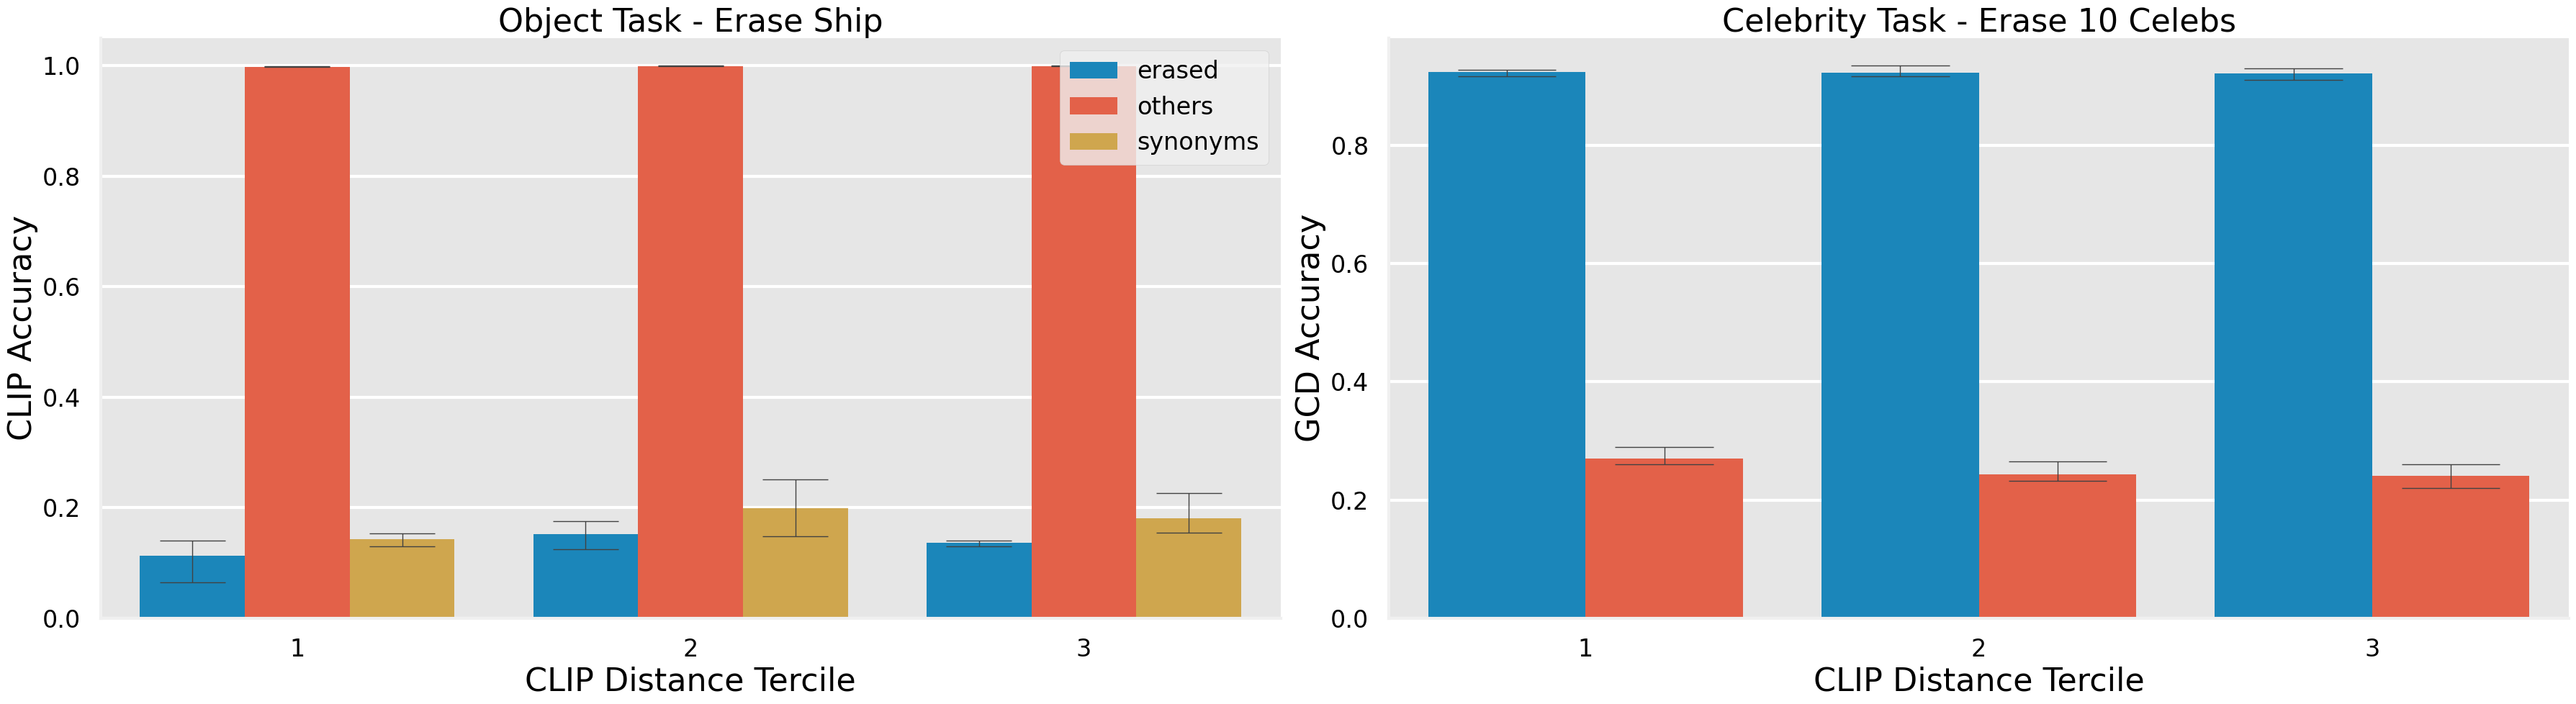

Figure saved as 'figures/clip_distance/all_tasks_clip_distance.png'


In [76]:
# Create a main figure with subplots for each task
tasks = ['object', 'celebrity']
x_axis_labels = {
    'erase_ship': 'Erase Ship',
    'erase_bird': 'Erase Bird',
    'erase_automobile': 'Erase Automobile',
    'erase_cele_1': 'Erase 1 Celeb',
    'erase_cele_5': 'Erase 5 Celebs',
    'erase_cele_10': 'Erase 10 Celebs',
    'erase_cele_100': 'Erase 100 Celebs'
}

fig, axes = plt.subplots(1, len(tasks), figsize=(36, 10))
fig.patch.set_facecolor('white')  # Set figure background to white

change = 'CLIP Distance'
change_str = 'baseline'

for idx, task in enumerate(tasks):

    metric = metric_map[task]

    plt.style.use('fivethirtyeight')

    df_fig = df[df['change'].str.contains(change_str, na=False)]
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[df_fig['finetune_prompts'].str.contains("clip_", na=False)]
    if task == 'art':
        df_fig['type'] = df_fig['type'].map({"0": "erased", "1": "others"})
    
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    
    # Filter for 'full' and 'lora' finetune_algo
    df_fig = df_fig[df_fig['finetune_algo'].isin(['lora'])]

    grouped = df_fig.groupby(['finetune_prompts', 'type'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print("The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)

  
    ax = axes[idx]
    ax.set_facecolor('white')  # Set axes background to white
    
    # remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    

    # Sort the DataFrame based on the number at the end of finetune_prompts
    df_fig['prompt_number'] = df_fig['finetune_prompts'].str.extract('(\d+)$').astype(int)
    df_fig['prompt_number'] = df_fig['prompt_number'] + 1
    df_fig = df_fig.sort_values('prompt_number')
    
    custom_order = df_fig['finetune_prompts'].unique()
    ax.set_xlabel('CLIP Distance Tercile')
    ax.set_xticklabels(df_fig['prompt_number'].unique())

    # Plot the data with finetune_algo on x-axis and type as hue
    sns.barplot(data=df_fig, x='finetune_prompts', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)

    ax.set_title(f'{task.capitalize()} Task - {x_axis_labels[df_fig["config"].iloc[0]]}', fontsize=32)
    ax.tick_params(axis='x', rotation=0)

    # set font size of legend, x axis labels, y axis labels
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)
    
    # Increase space between x-axis labels and plot
    ax.tick_params(axis='x', which='major', pad=20)
    ax.tick_params(axis='y', which='major', pad=20)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=24)
    # set font size of ylabel
    ax.set_ylabel(metric_str[metric], fontsize=32)
    ax.set_xlabel('CLIP Distance Tercile', fontsize=32)
    ax.tick_params(axis='x', rotation=0)

    ax.set_facecolor('#E6E6E6')  # Light gray background
    ax.grid(color='white', linestyle='-', linewidth=3, axis='y')
    ax.set_axisbelow(True)  # Ensure grid is behind the bars


    handles, labels = ax.get_legend_handles_labels()
    if idx == 0:  # Only show legend for the first subplot
        ax.legend(handles, labels, title='', loc='upper right', fontsize=24)
    else:
        ax.legend().remove()

plt.tight_layout()
plt.show()

# Save the figure
os.makedirs('figures/clip_distance', exist_ok=True)
fig.savefig(f'figures/clip_distance/all_tasks_clip_distance.png', dpi=300, bbox_inches='tight', facecolor='white')
print(f"Figure saved as 'figures/clip_distance/all_tasks_clip_distance.png'")
    

/tmp/ipykernel_305169/4159425126.py:38: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='finetune_task', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)
/tmp/ipykernel_305169/4159425126.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_fig['finetune_task'].unique())


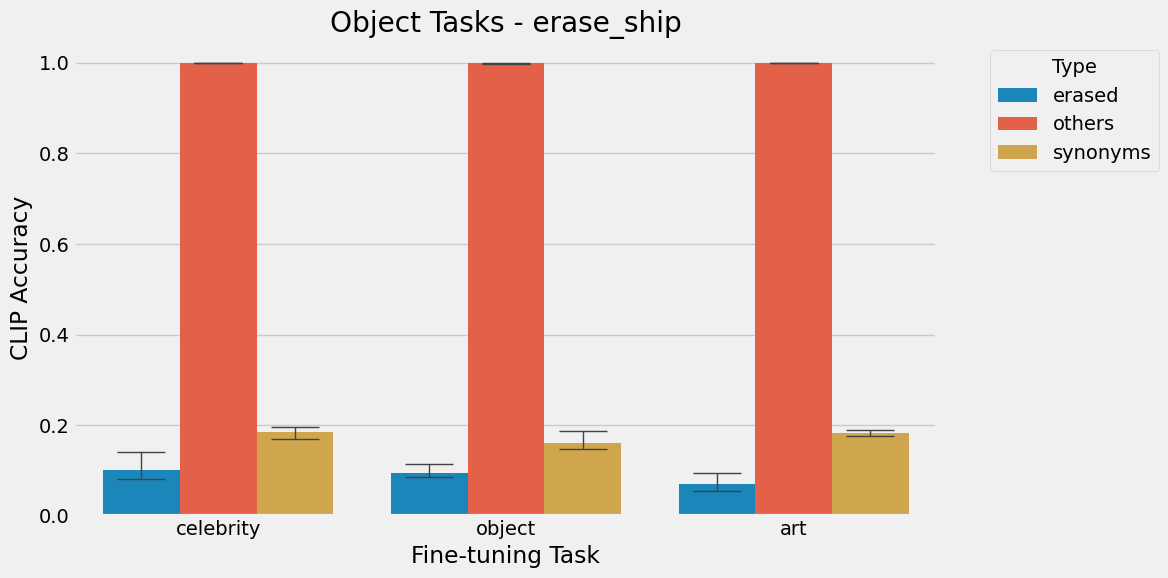

Figure saved as 'figures/in_vs_out_domain/object_in_vs_out_domain.png'
The following groups have an incorrect number of values:
Group ('art', 'erased') has 4 values:
    algo    change task         config finetune_algo finetune_task  \
49  MACE  baseline  art  erase_art_100          lora           art   
65  MACE  baseline  art  erase_art_100          lora           art   
79  MACE  baseline  art  erase_art_100          lora           art   
81  MACE  baseline  art  erase_art_100          lora           art   

             finetune_prompts       prompts_csv  seed    type      metric  \
49  art_random_concepts_seed0  art_100_concepts     1  erased  clip_score   
65  art_random_concepts_seed0  art_100_concepts     2  erased  clip_score   
79  art_random_concepts_seed0  art_100_concepts     0  erased  clip_score   
81  art_random_concepts_seed0  art_100_concepts     0  erased  clip_score   

      value  
49  21.6982  
65  21.6903  
79  21.4977  
81  21.4977  
Group ('art', 'others') has

/tmp/ipykernel_305169/4159425126.py:38: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='finetune_task', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)
/tmp/ipykernel_305169/4159425126.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_fig['finetune_task'].unique())


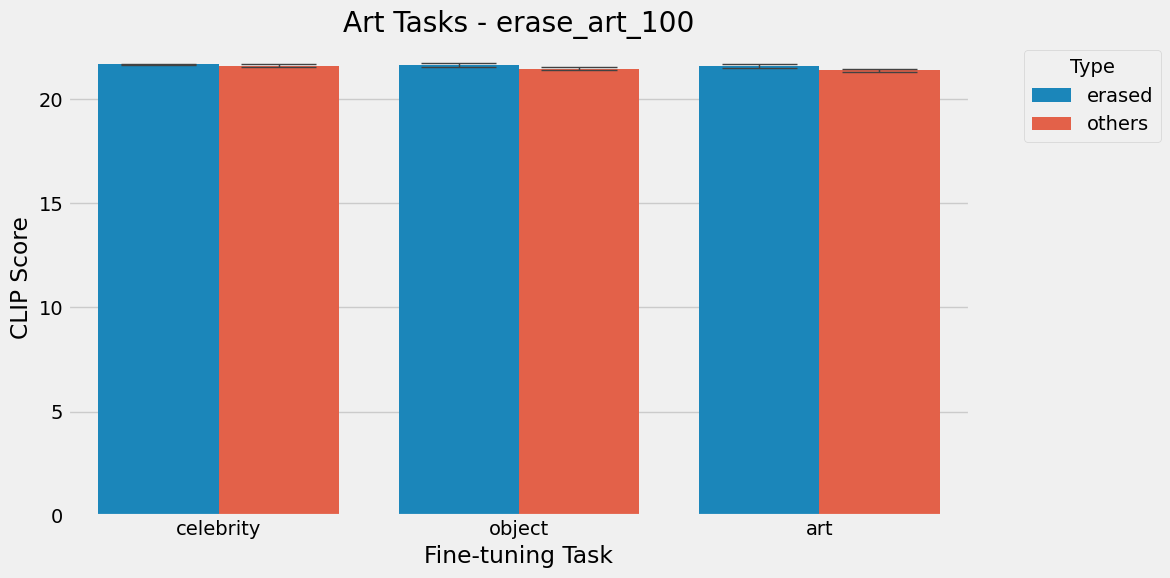

Figure saved as 'figures/in_vs_out_domain/art_in_vs_out_domain.png'


/tmp/ipykernel_305169/4159425126.py:38: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='finetune_task', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)
/tmp/ipykernel_305169/4159425126.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_fig['finetune_task'].unique())


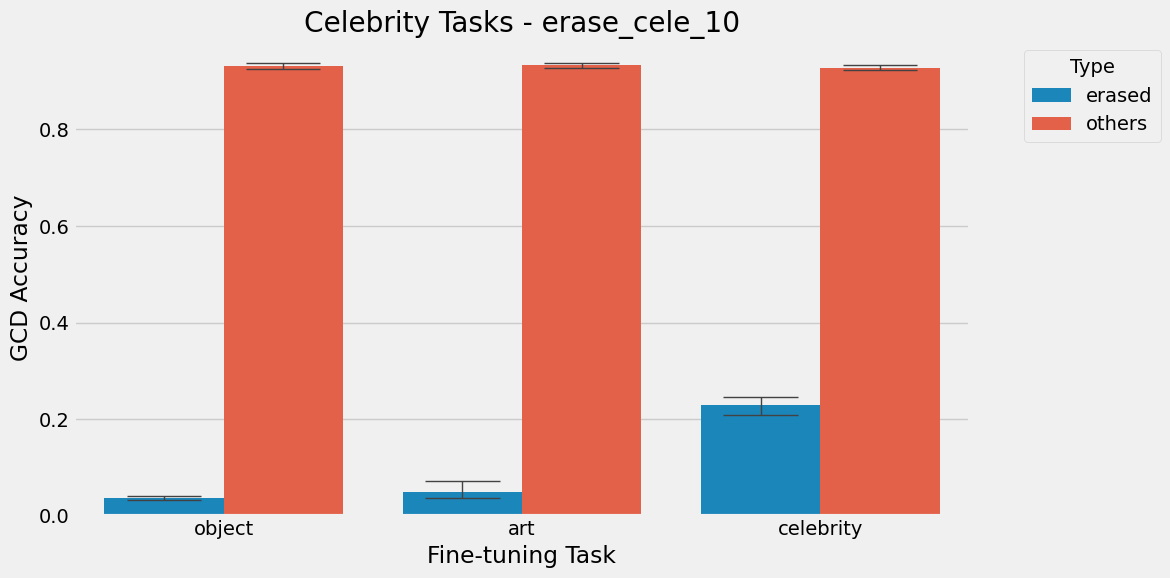

Figure saved as 'figures/in_vs_out_domain/celebrity_in_vs_out_domain.png'


In [77]:
change = 'In vs Out of Domain'
change_str = 'baseline'

for task in ['object', 'art', 'celebrity']:

    metric = metric_map[task]

    plt.style.use('fivethirtyeight')

    df_fig = df[df['change'].str.contains(change_str, na=False)]
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)]
    
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    df_fig = df_fig[df_fig['config'].isin(['erase_ship', 'erase_cele_10', 'erase_art_100'])]    # Filter for 'full' and 'lora' finetune_algo, and 'erase_cele_10' config
    df_fig = df_fig[df_fig['finetune_algo'].isin(['lora'])]
    if task == 'art':
        df_fig['type'] = df_fig['type'].map({"0": "erased", "1": "others"})

    grouped = df_fig.groupby(['finetune_task', 'type'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print("The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)


    fig, ax = plt.subplots(figsize=(12, 6))

    ax.set_xlabel('Fine-tuning Task')
    

    # Plot the data with finetune_algo on x-axis and type as hue
    sns.barplot(data=df_fig, x='finetune_task', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)

    ax.set_title(f'{task.capitalize()} Tasks - {df_fig["config"].iloc[0]}')
    ax.set_ylabel(metric_str[metric])
    ax.tick_params(axis='x', rotation=0)
    ax.set_xticklabels(df_fig['finetune_task'].unique())

    ax.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    # Create the 'figures/warmup' directory if it doesn't exist
    import os
    os.makedirs('figures/in_vs_out_domain', exist_ok=True)

    # Save the figure
    fig.savefig(f'figures/in_vs_out_domain/{task}_in_vs_out_domain.png', dpi=300, bbox_inches='tight')
    print(f"Figure saved as 'figures/in_vs_out_domain/{task}_in_vs_out_domain.png'")

/tmp/ipykernel_305169/4256393912.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_fig['prompt_number'].unique())
/tmp/ipykernel_305169/4256393912.py:68: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='finetune_task', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)
/tmp/ipykernel_305169/4256393912.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_fig['finetune_task'].unique())
/tmp/ipykernel_305169/4256393912.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)
/tmp/ipykernel_305169/4256393912.py:84: UserWarning: set_t

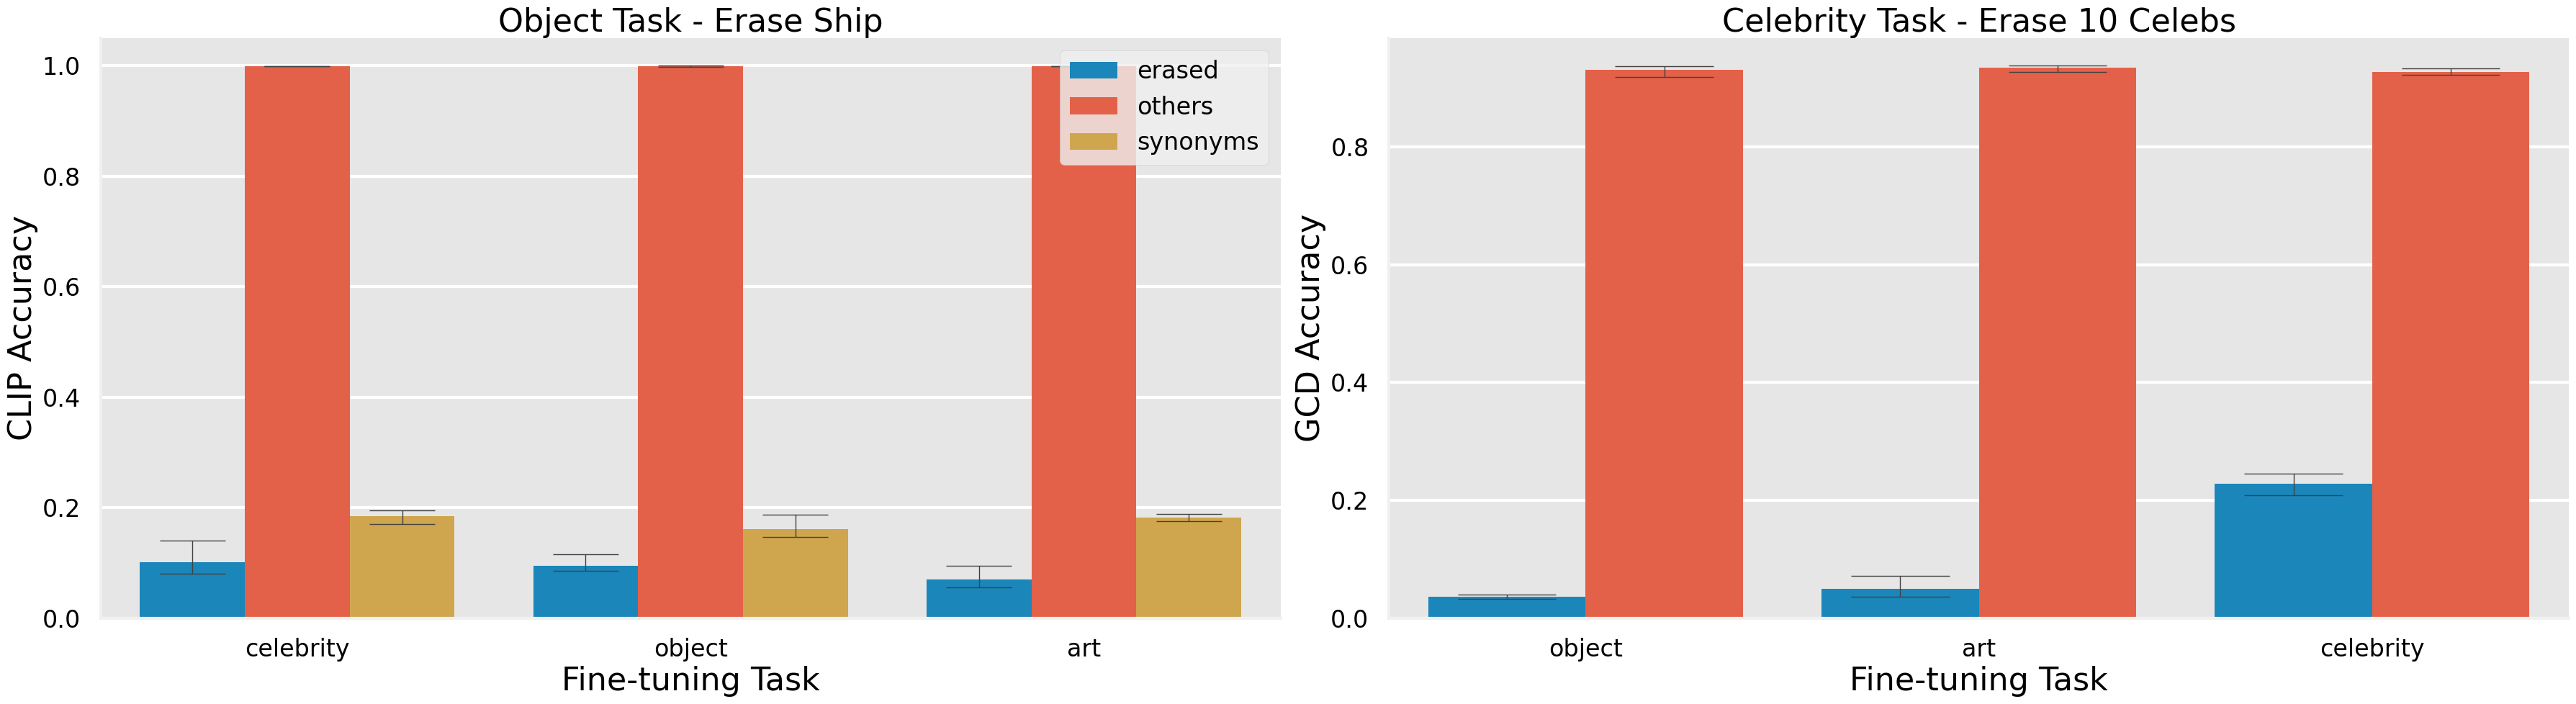

Figure saved as 'figures/in_vs_out_domain/all_tasks_in_vs_out_domain.png'


In [78]:
# Create a main figure with subplots for each task
tasks = ['object', 'celebrity']
x_axis_labels = {
    'erase_ship': 'Erase Ship',
    'erase_bird': 'Erase Bird',
    'erase_automobile': 'Erase Automobile',
    'erase_cele_1': 'Erase 1 Celeb',
    'erase_cele_5': 'Erase 5 Celebs',
    'erase_cele_10': 'Erase 10 Celebs',
    'erase_cele_100': 'Erase 100 Celebs'
}

fig, axes = plt.subplots(1, len(tasks), figsize=(36, 10))
fig.patch.set_facecolor('white')  # Set figure background to white

change = 'In vs Out of Domain'
change_str = 'baseline'

for idx, task in enumerate(tasks):

    metric = metric_map[task]

    plt.style.use('fivethirtyeight')

    df_fig = df[df['change'].str.contains(change_str, na=False)]
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)]
    
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    df_fig = df_fig[df_fig['config'].isin(['erase_ship', 'erase_cele_10', 'erase_art_100'])]    # Filter for 'full' and 'lora' finetune_algo, and 'erase_cele_10' config
    df_fig = df_fig[df_fig['finetune_algo'].isin(['lora'])]
    if task == 'art':
        df_fig['type'] = df_fig['type'].map({"0": "erased", "1": "others"})

    grouped = df_fig.groupby(['finetune_task', 'type'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print("The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)

  
    ax = axes[idx]
    ax.set_facecolor('white')  # Set axes background to white
    
    # remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    

    # Sort the DataFrame based on the number at the end of finetune_prompts
    df_fig['prompt_number'] = df_fig['finetune_prompts'].str.extract('(\d+)$').astype(int)
    df_fig['prompt_number'] = df_fig['prompt_number'] + 1
    df_fig = df_fig.sort_values('prompt_number')
    
    custom_order = df_fig['finetune_prompts'].unique()
    ax.set_xlabel('CLIP Distance Tercile')
    ax.set_xticklabels(df_fig['prompt_number'].unique())

    # Plot the data with finetune_algo on x-axis and type as hue
     # Plot the data with finetune_algo on x-axis and type as hue
    sns.barplot(data=df_fig, x='finetune_task', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)

    ax.set_title(f'{task.capitalize()} Task - {x_axis_labels[df_fig["config"].iloc[0]]}', fontsize=32)
    ax.set_ylabel(metric_str[metric])
    ax.tick_params(axis='x', rotation=0)
    ax.set_xticklabels(df_fig['finetune_task'].unique())
    ax.set_ylabel(metric_str[metric], fontsize=32)
    ax.set_xlabel('Fine-tuning Task', fontsize=32)
    ax.tick_params(axis='x', rotation=0)

    # set font size of legend, x axis labels, y axis labels
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)
    
    # Increase space between x-axis labels and plot
    ax.tick_params(axis='x', which='major', pad=20)
    ax.tick_params(axis='y', which='major', pad=20)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=24)

    ax.set_facecolor('#E6E6E6')  # Light gray background
    ax.grid(color='white', linestyle='-', linewidth=3, axis='y')
    ax.set_axisbelow(True)  # Ensure grid is behind the bars

    

    handles, labels = ax.get_legend_handles_labels()
    if idx == 0:  # Only show legend for the first subplot
        ax.legend(handles, labels, title='', loc='upper right', fontsize=24)
    else:
        ax.legend().remove()

plt.tight_layout()
plt.show()

# Save the figure
os.makedirs('figures/in_vs_out_domain', exist_ok=True)
fig.savefig(f'figures/in_vs_out_domain/all_tasks_in_vs_out_domain.png', dpi=300, bbox_inches='tight', facecolor='white')
print(f"Figure saved as 'figures/in_vs_out_domain/all_tasks_in_vs_out_domain.png'")
    

The following groups have an incorrect number of values:
Group ('object', 'erased') has 2 values:
     algo  change    task      config finetune_algo finetune_task  \
528  MACE  object  object  erase_ship          lora        object   
531  MACE  object  object  erase_ship          lora        object   

                 finetune_prompts           prompts_csv  seed    type  \
528  object_random_concepts_seed0  object_ship_concepts     1  erased   
531  object_random_concepts_seed0  object_ship_concepts     0  erased   

       metric  value mapping_value  
528  clip_acc   0.22        object  
531  clip_acc   0.24        object  
Group ('object', 'others') has 2 values:
     algo  change    task      config finetune_algo finetune_task  \
532  MACE  object  object  erase_ship          lora        object   
529  MACE  object  object  erase_ship          lora        object   

                 finetune_prompts           prompts_csv  seed    type  \
532  object_random_concepts_seed0  object

/tmp/ipykernel_305169/2485323422.py:73: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='change', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)


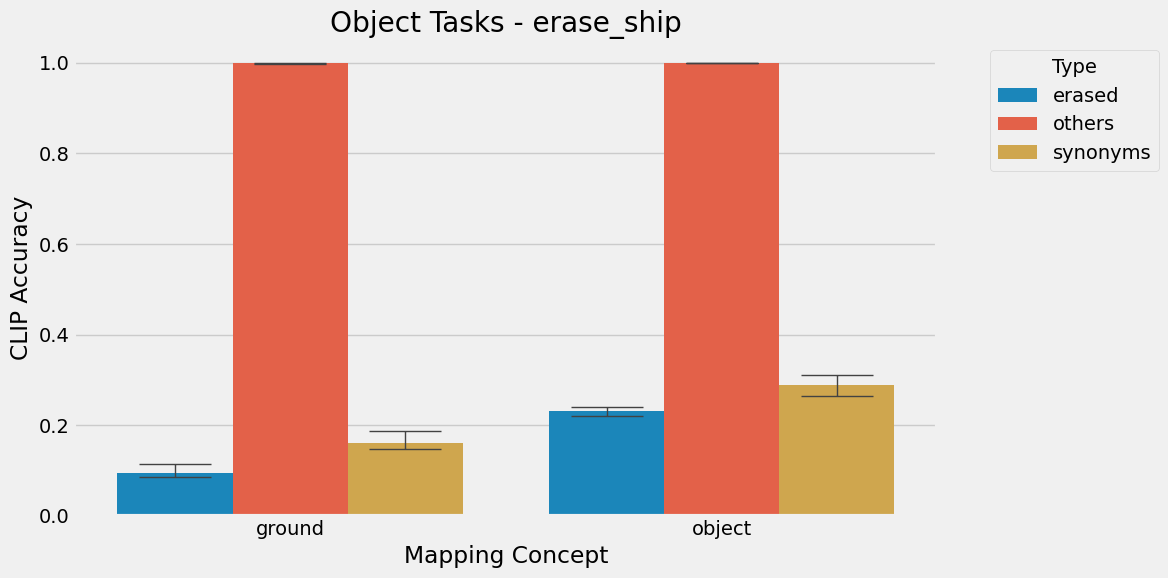

Figure saved as 'figures/mapping_concept/object_mapping_concept.png'
The following groups have an incorrect number of values:
Group ('baseline', 'erased') has 4 values:
    algo    change task         config finetune_algo finetune_task  \
49  MACE  baseline  art  erase_art_100          lora           art   
81  MACE  baseline  art  erase_art_100          lora           art   
79  MACE  baseline  art  erase_art_100          lora           art   
65  MACE  baseline  art  erase_art_100          lora           art   

             finetune_prompts       prompts_csv  seed    type      metric  \
49  art_random_concepts_seed0  art_100_concepts     1  erased  clip_score   
81  art_random_concepts_seed0  art_100_concepts     0  erased  clip_score   
79  art_random_concepts_seed0  art_100_concepts     0  erased  clip_score   
65  art_random_concepts_seed0  art_100_concepts     2  erased  clip_score   

      value mapping_value  
49  21.6982      baseline  
81  21.4977      baseline  
79  21.497

/tmp/ipykernel_305169/2485323422.py:73: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='change', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)


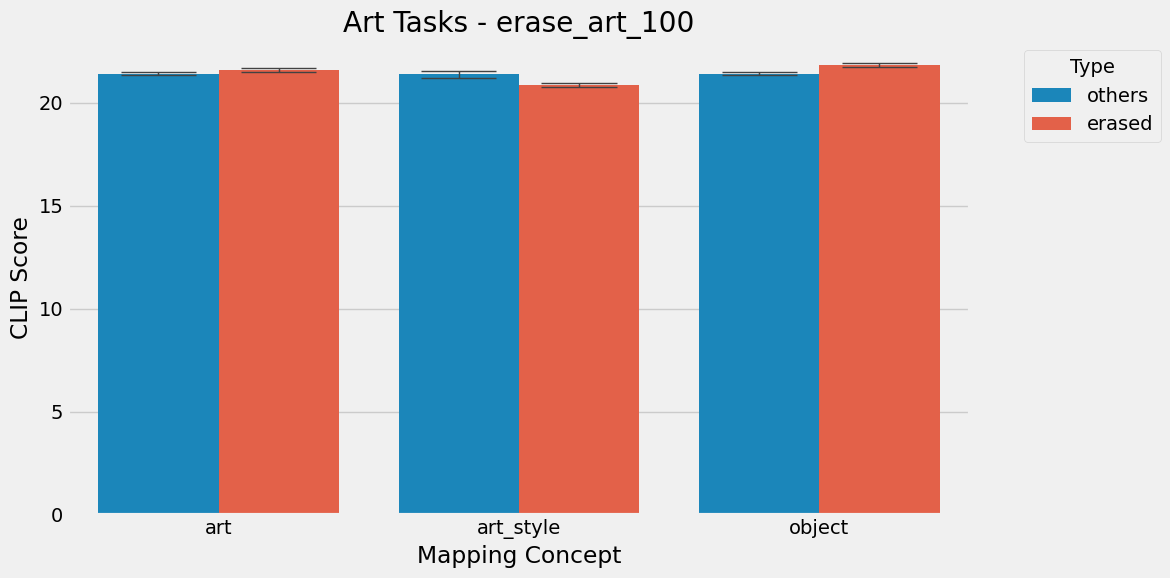

Figure saved as 'figures/mapping_concept/art_mapping_concept.png'
The following groups have an incorrect number of values:
Group ('gender_celebrity', 'others') has 2 values:
     algo            change       task         config finetune_algo  \
408  MACE  gender_celebrity  celebrity  erase_cele_10          lora   
406  MACE  gender_celebrity  celebrity  erase_cele_10          lora   

    finetune_task                 finetune_prompts            prompts_csv  \
408     celebrity  celebrity_random_concepts_seed0  celebrity_10_concepts   
406     celebrity  celebrity_random_concepts_seed0  celebrity_10_concepts   

     seed    type metric     value     mapping_value  
408     2  others    GCD  0.928659  gender_celebrity  
406     0  others    GCD  0.931967  gender_celebrity  
Group ('object', 'erased') has 2 values:
     algo  change       task         config finetune_algo finetune_task  \
546  MACE  object  celebrity  erase_cele_10          lora     celebrity   
544  MACE  object  celeb

/tmp/ipykernel_305169/2485323422.py:73: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='change', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)


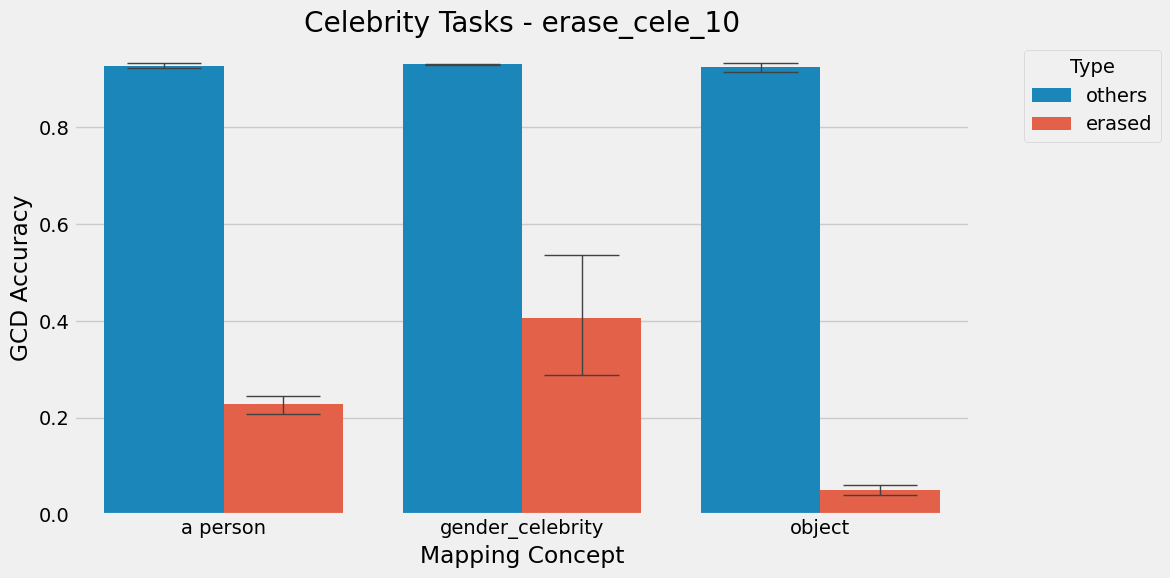

Figure saved as 'figures/mapping_concept/celebrity_mapping_concept.png'


In [79]:
change = 'Mapping Concept'
change_str = 'mapping='

for task in ['object', 'art', 'celebrity']:

    metric = metric_map[task]

    plt.style.use('fivethirtyeight')

    df_fig = df[(df['change'].str.contains(change_str, na=False)) | (df['change'] == 'baseline')]
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)]
    df_fig = df_fig[df_fig['finetune_task'] == task]
    
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    df_fig['config'] = df_fig['config'].apply(lambda x: 'erase_ship' if x.startswith('erase_ship_') else
                                              ('erase_cele_10' if x.startswith('erase_cele_10_') else
                                               ('erase_art_100' if x.startswith('erase_art_100_') else x)))
    
    df_fig['mapping_value'] = df_fig['change'].apply(lambda x: x.split('=')[-1] if '=' in x else 'baseline')
    
    df_fig = df_fig.sort_values('mapping_value')
    
    df_fig['change'] = df_fig['mapping_value']
    df_fig = df_fig[df_fig['config'].isin(['erase_ship', 'erase_cele_10', 'erase_art_100'])]    # Filter for 'full' and 'lora' finetune_algo, and 'erase_cele_10' config
    df_fig = df_fig[df_fig['finetune_algo'].isin(['lora'])]
    if task == 'art':
        df_fig['type'] = df_fig['type'].map({"0": "erased", "1": "others"})
    
    grouped = df_fig.groupby(['change', 'type'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print("The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)

    # Create a mapping for baseline concepts
    baseline_mapping = {
        'celebrity': 'a person',
        'art': 'art',
        'object': {
            'erase_ship': 'ground',
            'erase_bird': 'street',
            'erase_automobile': 'sky'
        }
    }

    # Function to extract mapping concept or use baseline
    def get_mapping_concept(change, task, config):
        if change == 'baseline':
            if task == 'object':
                return baseline_mapping[task][config]
            else:
                return baseline_mapping[task]   
        else:
            return change.split('=')[-1]

    # Apply the function to create a new column for x-axis labels
    df_fig['mapping_concept'] = df_fig.apply(lambda row: get_mapping_concept(row['change'], task, row['config']), axis=1)

    # Sort the dataframe by the new mapping_concept column
    df_fig = df_fig.sort_values('mapping_concept')

    # Update the 'change' column to use the new mapping_concept
    df_fig['change'] = df_fig['mapping_concept']
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.set_xlabel('Mapping Concept')
    sns.barplot(data=df_fig, x='change', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)

    ax.set_title(f'{task.capitalize()} Tasks - {df_fig["config"].iloc[0]}')
    ax.set_ylabel(metric_str[metric])
    ax.tick_params(axis='x', rotation=0)

    ax.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    # Create the 'figures/warmup' directory if it doesn't exist
    import os
    os.makedirs('figures/mapping_concept', exist_ok=True)

    # Save the figure
    fig.savefig(f'figures/mapping_concept/{task}_mapping_concept.png', dpi=300, bbox_inches='tight')
    print(f"Figure saved as 'figures/mapping_concept/{task}_mapping_concept.png'")

The following groups have an incorrect number of values:
Group ('object', 'erased') has 2 values:
     algo  change    task      config finetune_algo finetune_task  \
528  MACE  object  object  erase_ship          lora        object   
531  MACE  object  object  erase_ship          lora        object   

                 finetune_prompts           prompts_csv  seed    type  \
528  object_random_concepts_seed0  object_ship_concepts     1  erased   
531  object_random_concepts_seed0  object_ship_concepts     0  erased   

       metric  value mapping_value  
528  clip_acc   0.22        object  
531  clip_acc   0.24        object  
Group ('object', 'others') has 2 values:
     algo  change    task      config finetune_algo finetune_task  \
532  MACE  object  object  erase_ship          lora        object   
529  MACE  object  object  erase_ship          lora        object   

                 finetune_prompts           prompts_csv  seed    type  \
532  object_random_concepts_seed0  object

/tmp/ipykernel_305169/2686812610.py:101: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='change', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)
/tmp/ipykernel_305169/2686812610.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)
/tmp/ipykernel_305169/2686812610.py:118: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=24)
/tmp/ipykernel_305169/2686812610.py:101: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.barplot(data=df_fig, x='change', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)
/tmp/ipykernel_305

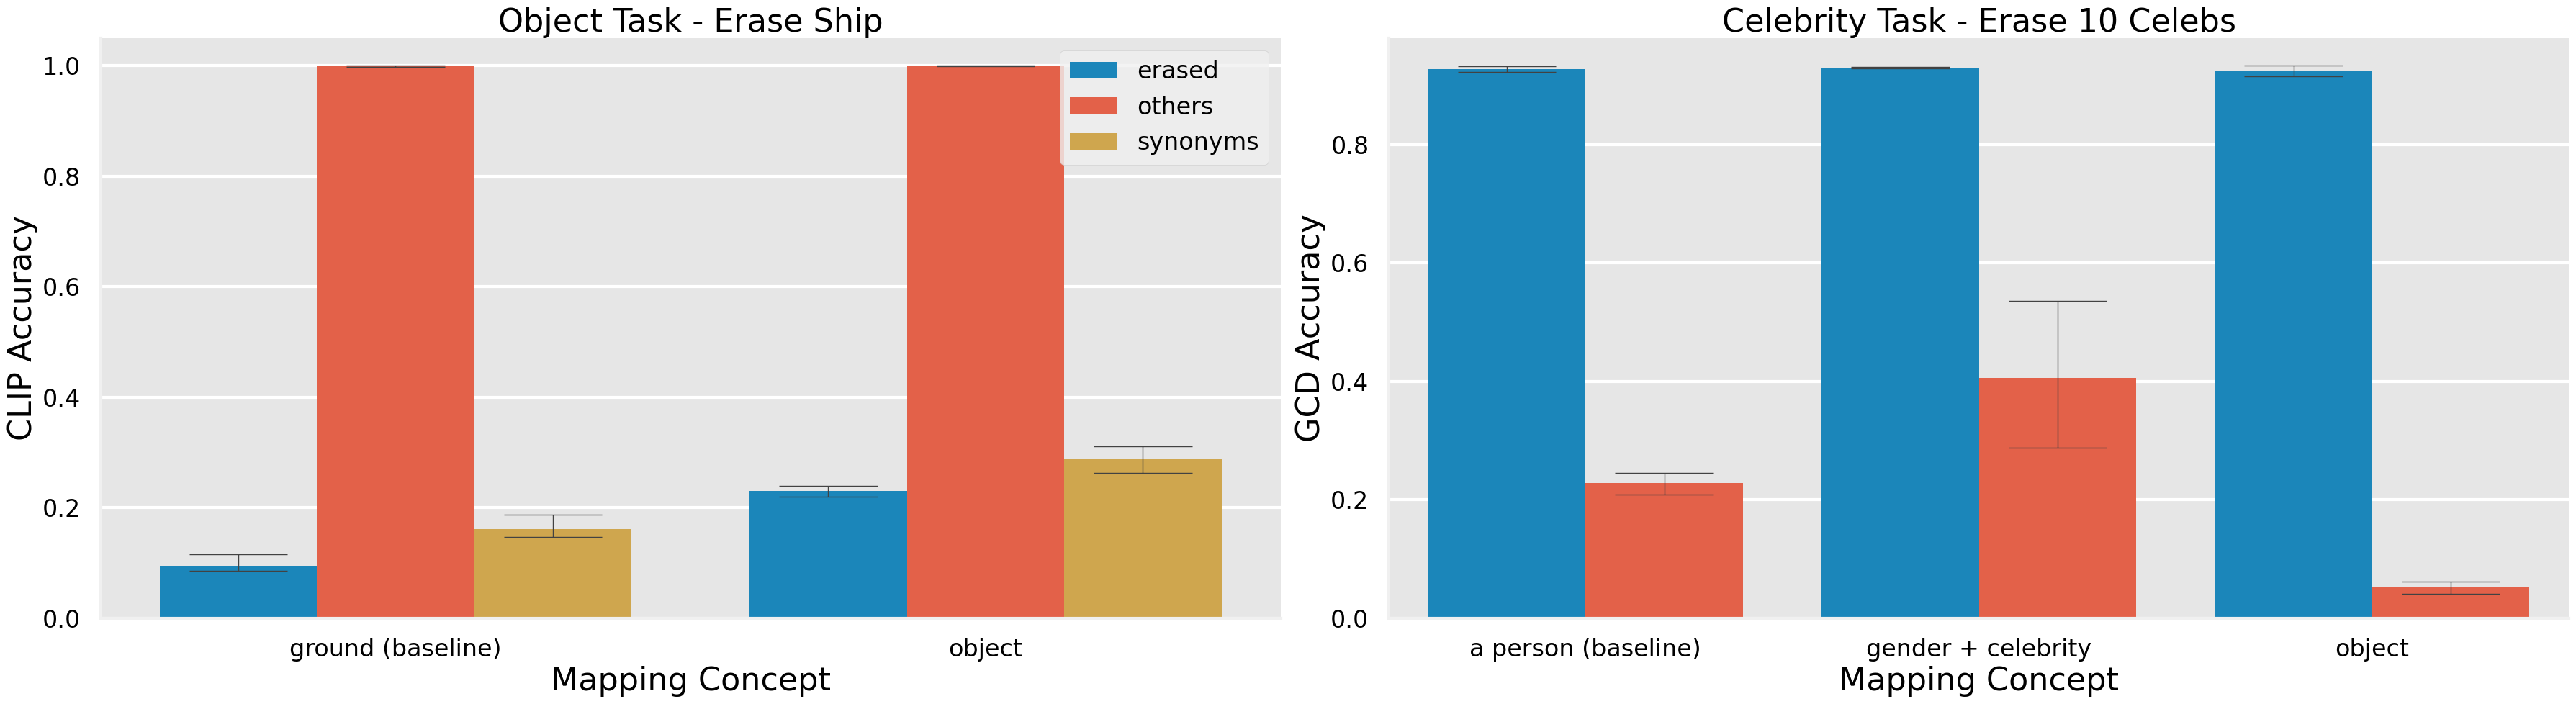

Figure saved as 'figures/mapping_concept/all_tasks_mapping_concept.png'


In [80]:
# Create a main figure with subplots for each task
tasks = ['object', 'celebrity']
x_axis_labels = {
    'erase_ship': 'Erase Ship',
    'erase_bird': 'Erase Bird',
    'erase_automobile': 'Erase Automobile',
    'erase_cele_1': 'Erase 1 Celeb',
    'erase_cele_5': 'Erase 5 Celebs',
    'erase_cele_10': 'Erase 10 Celebs',
    'erase_cele_100': 'Erase 100 Celebs'
}

fig, axes = plt.subplots(1, len(tasks), figsize=(36, 10))
fig.patch.set_facecolor('white')  # Set figure background to white

change = 'Mapping Concept'
change_str = 'mapping='

for idx, task in enumerate(tasks):

    metric = metric_map[task]

    plt.style.use('fivethirtyeight')

    df_fig = df[(df['change'].str.contains(change_str, na=False)) | (df['change'] == 'baseline')]
    df_fig = df_fig[df_fig['task'] == task]
    df_fig = df_fig[df_fig['metric'] == metric]
    df_fig = df_fig[df_fig['finetune_prompts'].str.contains("_random_concepts_seed0", na=False)]
    df_fig = df_fig[df_fig['finetune_task'] == task]
    
    df_fig['value'] = df_fig['value'].apply(lambda x: float(x.split('±')[0]) if isinstance(x, str) and '±' in x else float(x))
    df_fig['config'] = df_fig['config'].apply(lambda x: 'erase_ship' if x.startswith('erase_ship_') else
                                              ('erase_cele_10' if x.startswith('erase_cele_10_') else
                                               ('erase_art_100' if x.startswith('erase_art_100_') else x)))
    
    df_fig['mapping_value'] = df_fig['change'].apply(lambda x: x.split('=')[-1] if '=' in x else 'baseline')
    
    df_fig = df_fig.sort_values('mapping_value')
    
    df_fig['change'] = df_fig['mapping_value']
    df_fig = df_fig[df_fig['config'].isin(['erase_ship', 'erase_cele_10', 'erase_art_100'])]    # Filter for 'full' and 'lora' finetune_algo, and 'erase_cele_10' config
    df_fig = df_fig[df_fig['finetune_algo'].isin(['lora'])]
    if task == 'art':
        df_fig['type'] = df_fig['type'].map({"0": "erased", "1": "others"})
    
    grouped = df_fig.groupby(['change', 'type'])
    invalid_groups = [name for name, group in grouped if len(group) != 3]
    
    if invalid_groups:
        print("The following groups have an incorrect number of values:")
        for name in invalid_groups:
            group = grouped.get_group(name)
            print(f"Group {name} has {len(group)} values:")
            print(group)

    # Create a mapping for baseline concepts
    baseline_mapping = {
        'celebrity': 'a person (baseline)',
        'art': 'art (baseline)',
        'object': {
            'erase_ship': 'ground (baseline)',
            'erase_bird': 'street (baseline)',
            'erase_automobile': 'sky (baseline)'
        }
    }

    # Function to extract mapping concept or use baseline
    def get_mapping_concept(change, task, config):
        if change == 'baseline':
            if task == 'object':
                return baseline_mapping[task][config]
            else:
                return baseline_mapping[task]   
        elif 'gender_celebrity' in change:
            return 'gender + celebrity'
        else:
            return change.split('=')[-1]

    # Apply the function to create a new column for x-axis labels
    df_fig['mapping_concept'] = df_fig.apply(lambda row: get_mapping_concept(row['change'], task, row['config']), axis=1)

    # Sort the dataframe by the new mapping_concept column
    df_fig = df_fig.sort_values('mapping_concept')

    # Update the 'change' column to use the new mapping_concept
    df_fig['change'] = df_fig['mapping_concept']

  
    ax = axes[idx]
    ax.set_facecolor('white')  # Set axes background to white
    
    # remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    

    ax.set_xlabel('Mapping Concept', fontsize=32)
    
    sns.barplot(data=df_fig, x='change', y='value', hue='type', ax=ax, capsize=0.5, errwidth=1)

    ax.set_title(f'{task.capitalize()} Task - {x_axis_labels[df_fig["config"].iloc[0]]}', fontsize=32)
    ax.set_ylabel(metric_str[metric])
    ax.tick_params(axis='x', rotation=0)
    ax.set_ylabel(metric_str[metric], fontsize=32)


    # set font size of legend, x axis labels, y axis labels
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)
    
    # Increase space between x-axis labels and plot
    ax.tick_params(axis='x', which='major', pad=20)
    ax.tick_params(axis='y', which='major', pad=20)
    # Move y-axis label away from the y-axis
    #ax.yaxis.set_label_coords(-0.05, 0.5)
    #plt.subplots_adjust(wspace=0.5)  # Adjust this value as needed
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=24)

    # Set gray background with white grid lines
    ax.set_facecolor('#E6E6E6')  # Light gray background
    ax.grid(color='white', linestyle='-', linewidth=3, axis='y')
    ax.set_axisbelow(True)  # Ensure grid is behind the bars

    handles, labels = ax.get_legend_handles_labels()
    if idx == 0:  # Only show legend for the first subplot
        ax.legend(handles, labels, title='', loc='upper right', fontsize=24)
    else:
        ax.legend().remove()

plt.tight_layout()
plt.show()

# Save the figure
os.makedirs('figures/mapping_concept', exist_ok=True)
fig.savefig(f'figures/mapping_concept/all_tasks_mapping_concept.png', dpi=300, bbox_inches='tight', facecolor='white')
print(f"Figure saved as 'figures/mapping_concept/all_tasks_mapping_concept.png'")
    